# Running The 3 Architectures on Cifar-10

# All CNN Experiments Performed using Google Colab's T4 GPU

## firstly the standard 1-layer cnn:

In [1]:
!nvidia-smi

Tue Sep  8 08:52:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
!git clone https://github.com/henrybattley/neurons-as-autoencoders.git

Cloning into 'neurons-as-autoencoders'...
remote: Enumerating objects: 1317, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 1317 (delta 58), reused 51 (delta 29), pack-reused 1229 (from 1)
Receiving objects: 100% (1317/1317), 3.76 MiB | 5.96 MiB/s, done.
Resolving deltas: 100% (1006/1006), done.


In [2]:
%cd neurons-as-autoencoders
!git pull

/content/neurons-as-autoencoders
Already up to date.


# Imports...

In [3]:
import sys
import os
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
#get model
from src.models import cnn_model

#get experiment
from src.experiments import cnn_experiments

In [5]:
import random
import numpy as np
import pandas as pd
import torch, torchvision
import torch.nn as nn
from torchsummary import summary
import importlib
import matplotlib.pyplot as plt

# Getting Cifar-10 Data
### (At the time of programming, host servers of Cifar-10 (Toronto University) are incredibly slow for downloads, thus a kaggle mirror is instead downloaded)

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayush1220/cifar10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifar10' dataset.
Path to dataset files: /kaggle/input/cifar10


In [7]:
print(os.listdir(path))

['cifar10']


In [8]:
cifar_path = os.path.join(path, "cifar10")

In [9]:
print(os.listdir(cifar_path))

['test', 'train']


In [10]:
cifar_train_path = os.path.join(cifar_path,"train")

In [11]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

cifar_train = datasets.ImageFolder(
    root=cifar_train_path,
    transform=transform
)

print(len(cifar_train))
print(cifar_train.classes)
print(cifar_train.class_to_idx)

50000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [12]:
# images are already scaled by toTensor()
image, label = cifar_train[0]

print(image.shape)
print(image.dtype)
print(image.min(), image.max())
print(label)

torch.Size([3, 32, 32])
torch.float32
tensor(0.0078) tensor(0.9961)
0


# Preloading the data into tensor

In [13]:
loader = torch.utils.data.DataLoader(
    cifar_train,
    batch_size=1024,
    shuffle=False,
    num_workers=2
)

all_images = []
all_labels = []

for images, labels in loader:
    all_images.append(images)
    all_labels.append(labels)

cifar_images = torch.cat(all_images)
cifar_labels = torch.cat(all_labels)

cifar_train_tensor = torch.utils.data.TensorDataset(
    cifar_images,
    cifar_labels
)

print(cifar_images.shape)
print(cifar_labels.shape)

torch.Size([50000, 3, 32, 32])
torch.Size([50000])


### Making use of the standard cnn with 16 feature maps, no bias, padding of 1 and stride of 1 (thus feature maps retain the input size of 32x32)

In [ ]:
#count how many params of the model...

#just to make sure we are getting the most current file version 
importlib.reload(cnn_model)  

device = torch.device('cpu')

model = cnn_model.CNN(
        input_dims=32,
        in_channels=3,
        pool_kernel_size=2,
        pool_stride=2,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        classes=10,
        bias=False
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

conv1.weight         (16, 3, 3, 3) -> 432
fc.weight            (10, 4096) -> 40960
fc.bias              (10,) -> 10
41402


In [ ]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_cnn(
        cifar_train_tensor,
        input_dims=32,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        in_channels=3,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)




model run: 0
device is: cuda
Epoch [1/1], Training Loss: 1.7489, Training Accuracy: 38.84
peak memory from train : 73.30029296875
memory now reset and is: 21.96826171875 MB
time elapsed: 0.7849666039999192
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 1.7346, Training Accuracy: 39.15
Epoch [2/100], Training Loss: 1.4464, Training Accuracy: 49.98
Epoch [3/100], Training Loss: 1.3503, Training Accuracy: 53.51
Epoch [4/100], Training Loss: 1.2850, Training Accuracy: 55.88
Epoch [5/100], Training Loss: 1.2363, Training Accuracy: 57.60
Epoch [6/100], Training Loss: 1.1980, Training Accuracy: 59.14
Epoch [7/100], Training Loss: 1.1645, Training Accuracy: 60.06
Epoch [8/100], Training Loss: 1.1444, Training Accuracy: 60.91
Epoch [9/100], Training Loss: 1.1212, Training Accuracy: 61.45
Epoch [10/100], Training Loss: 1.1024, Training Accuracy: 62.61
Epoch [11/100], Training Loss: 1.0881, Training Accuracy: 62.75
Epoch [12/100], Training Loss: 1.0724, Training Accuracy: 63.35
Epoch 

In [ ]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})

epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_cifar_10_epoch_results.csv",
    index=False,
)


# Loss and Accuracy

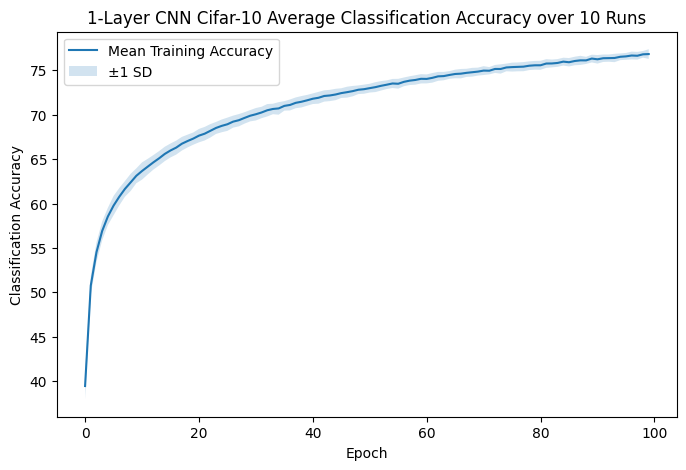

In [ ]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer CNN Cifar-10 Average Classification Accuracy over 10 Runs")
plt.show()

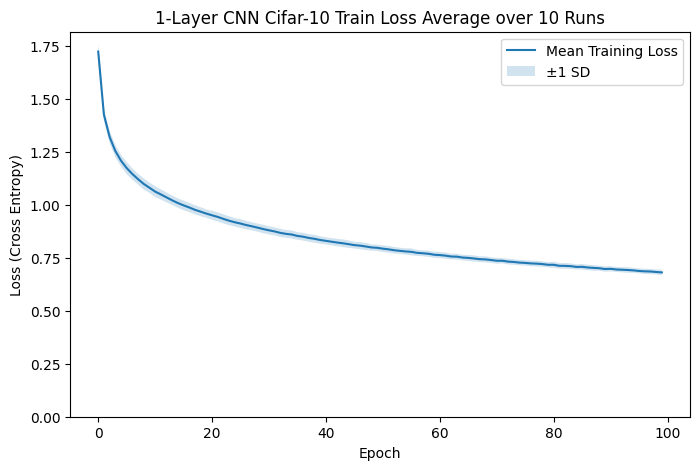

In [ ]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom =0)
plt.title("1-Layer CNN Cifar-10 Train Loss Average over 10 Runs")
plt.show()

# Memory overhead and Runtime

In [ ]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory


Mean max memory allocated: 70.331884765625
All peak memories (including the warm up run):


[73.30029296875,
 73.61767578125,
 69.966796875,
 69.966796875,
 69.966796875,
 69.966796875,
 69.966796875,
 69.966796875,
 69.966796875,
 69.966796875,
 69.966796875]

In [ ]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 87.9085710299 
All training times for the 100 epochs over the 10 runs:


array([ 87.21061412,  90.90030346,  94.49086134,  92.37879097,
        86.83479497, 101.98714232,  81.59514071,  81.13275426,
        78.98176658,  83.57354159])

# No Pooling, 32x32 feature maps

In [ ]:
from src.models import cnn_model_no_pooling

In [ ]:
#count how many params of the model...


device = torch.device('cpu')

model = cnn_model_no_pooling.CNN(
        input_dims=32,
        in_channels=3,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        classes=10,
        bias=False
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

In [13]:
all_train_histories = []
all_train_accuracies = []
peak_memory =[]
run_times= []


for seed in range(11): # 10 runs with one warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100


    model, training_history,elapsed = cnn_experiments.train_no_pool_cnn(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    run_times.append(elapsed)




model run: 0
device is: cuda
Epoch [1/1], Training Loss: 1.8526, Training Accuracy: 39.42
peak memory from train : 71.5244140625
memory now reset and is: 19.2548828125 MB
time elapsed: 1.2895511919996352
model run: 1
device is: cuda
Epoch [1/100], Training Loss: 1.8411, Training Accuracy: 38.84
Epoch [2/100], Training Loss: 1.4121, Training Accuracy: 50.82
Epoch [3/100], Training Loss: 1.3021, Training Accuracy: 54.94
Epoch [4/100], Training Loss: 1.2286, Training Accuracy: 57.74
Epoch [5/100], Training Loss: 1.1732, Training Accuracy: 59.70
Epoch [6/100], Training Loss: 1.1279, Training Accuracy: 61.37
Epoch [7/100], Training Loss: 1.0879, Training Accuracy: 62.52
Epoch [8/100], Training Loss: 1.0594, Training Accuracy: 63.82
Epoch [9/100], Training Loss: 1.0412, Training Accuracy: 64.32
Epoch [10/100], Training Loss: 1.0107, Training Accuracy: 65.55
Epoch [11/100], Training Loss: 0.9886, Training Accuracy: 66.22
Epoch [12/100], Training Loss: 0.9672, Training Accuracy: 66.88
Epoch [1

In [14]:
#make averages here

#avg loss
losses = np.array(all_train_histories[1:])
mean_loss = losses.mean(axis=0)
std_loss  = losses.std(axis=0)

#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
#saving results

epochs = np.arange(1, len(mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
})

epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/cnn_cifar_10_no_pool_epoch_results.csv",
    index=False,
)

# loss and accuracy

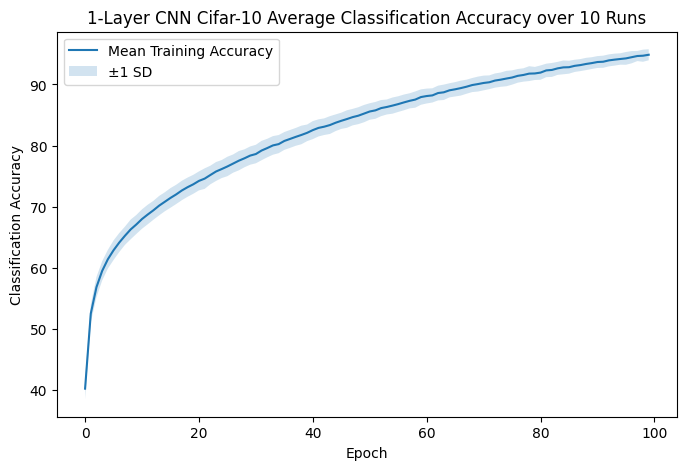

In [18]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer CNN Cifar-10 Average Classification Accuracy over 10 Runs")
plt.show()

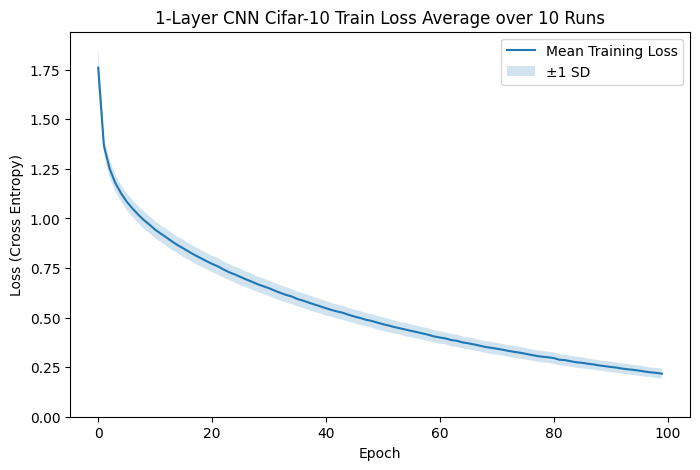

In [19]:
epochs = np.arange(len(mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom =0)
plt.title("1-Layer CNN Cifar-10 Train Loss Average over 10 Runs")
plt.show()

# memory and runtime

In [20]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory


Mean max memory allocated: 72.779296875
All peak memories (including the warm up run):


[71.5244140625,
 72.779296875,
 72.779296875,
 72.779296875,
 72.779296875,
 72.779296875,
 72.779296875,
 72.779296875,
 72.779296875,
 72.779296875,
 72.779296875]

In [21]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 78.86846103619996 
All training times for the 100 epochs over the 10 runs:


array([77.89555341, 77.65091407, 78.64527981, 78.98861312, 80.74578274,
       78.1753106 , 79.2169846 , 78.27698252, 79.3959071 , 79.6932824 ])

# Extracting features from the pooled version

In [13]:
all_train_histories = []
all_train_accuracies = []

peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_cnn_get_features(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Training Loss: 1.6732, Training Accuracy: 41.26
Epoch [2/100], Training Loss: 1.3545, Training Accuracy: 53.45
Epoch [3/100], Training Loss: 1.2603, Training Accuracy: 56.64
Epoch [4/100], Training Loss: 1.2082, Training Accuracy: 58.53
Epoch [5/100], Training Loss: 1.1757, Training Accuracy: 59.72
Epoch [6/100], Training Loss: 1.1358, Training Accuracy: 61.22
Epoch [7/100], Training Loss: 1.1104, Training Accuracy: 62.00
Epoch [8/100], Training Loss: 1.0880, Training Accuracy: 62.77
Epoch [9/100], Training Loss: 1.0730, Training Accuracy: 63.20
Epoch [10/100], Training Loss: 1.0481, Training Accuracy: 64.28
Epoch [11/100], Training Loss: 1.0333, Training Accuracy: 64.87
Epoch [12/100], Training Loss: 1.0193, Training Accuracy: 65.13
Epoch [13/100], Training Loss: 1.0026, Training Accuracy: 65.86
Epoch [14/100], Training Loss: 0.9891, Training Accuracy: 66.25
Epoch [15/100], Training Loss: 0.9775, Training Accuracy: 66.56
Epoch [16/100], Trai

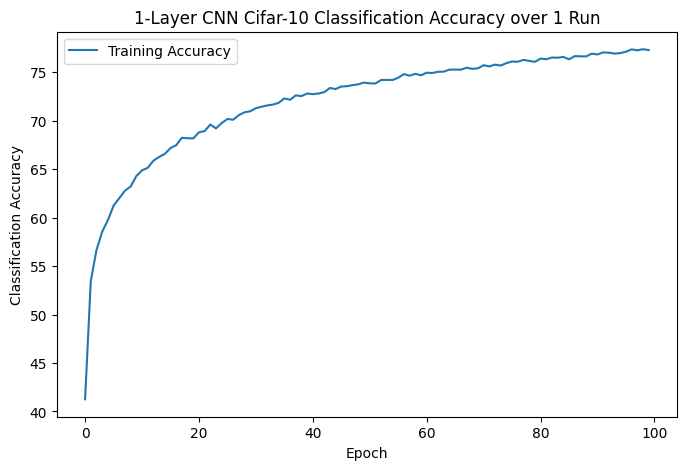

In [14]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")



plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer CNN Cifar-10 Classification Accuracy over 1 Run")
plt.show()

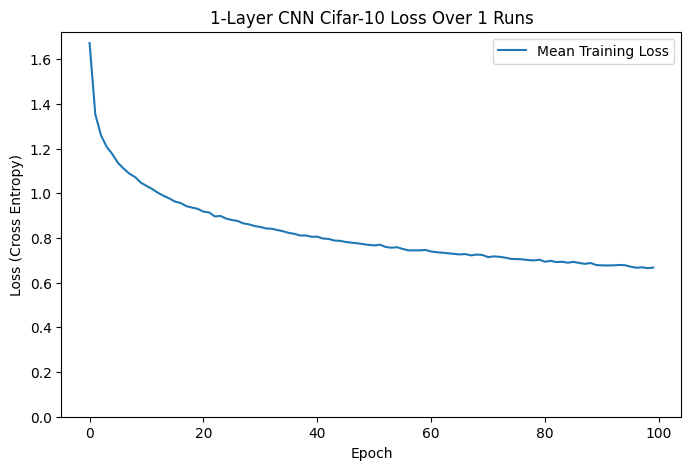

In [16]:
epochs = np.arange(len(training_history["train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_loss"],label="Mean Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom=0)
plt.title("1-Layer CNN Cifar-10 Loss Over 1 Runs")
plt.show()

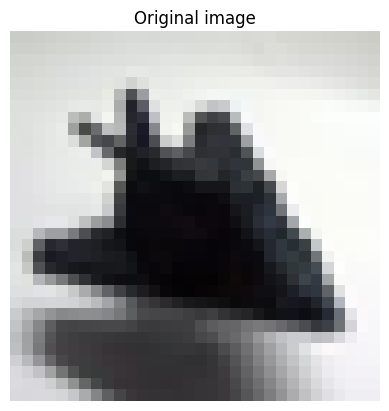

In [19]:
img = feature_history[epoch]["original"][0]

img = img.detach().cpu().permute(1, 2, 0)

plt.imshow(img)
plt.title("Original image")
plt.axis("off")
plt.show()

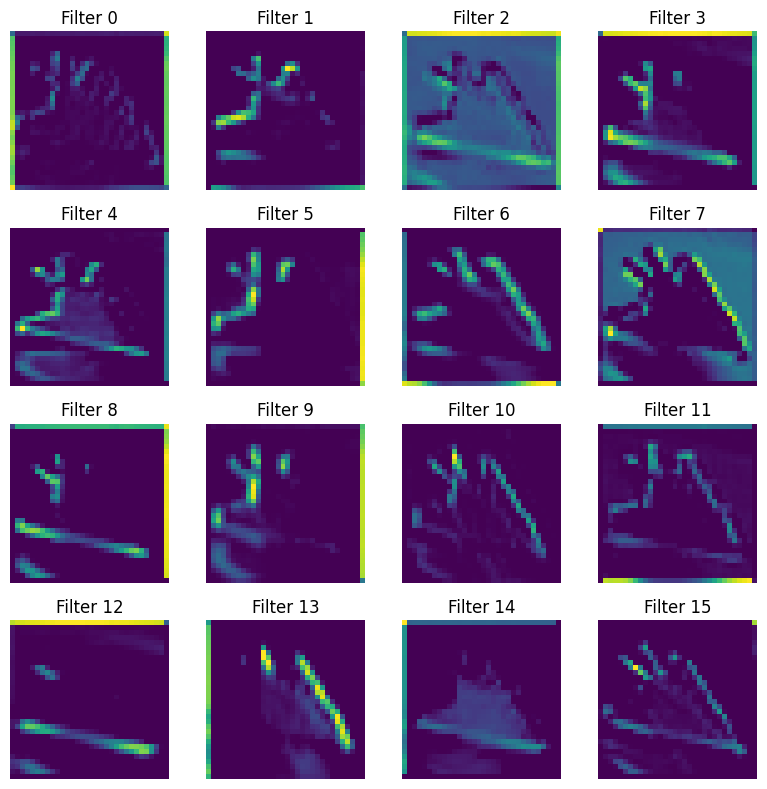

In [23]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

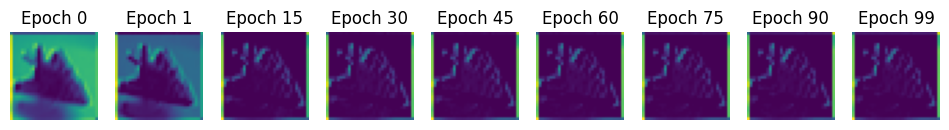

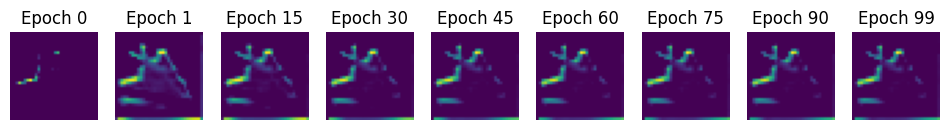

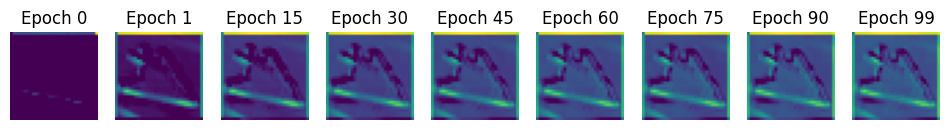

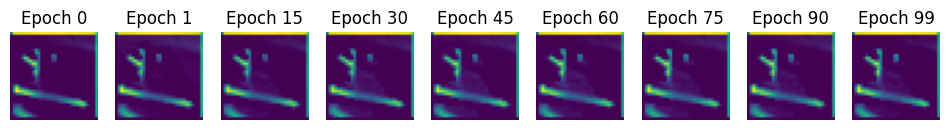

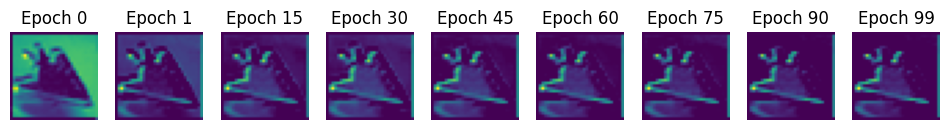

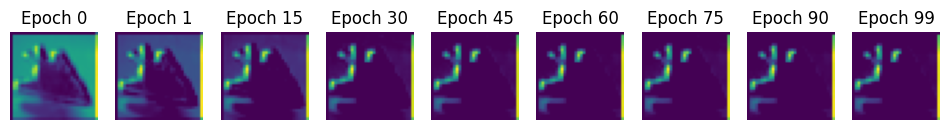

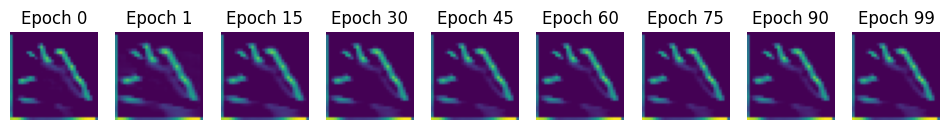

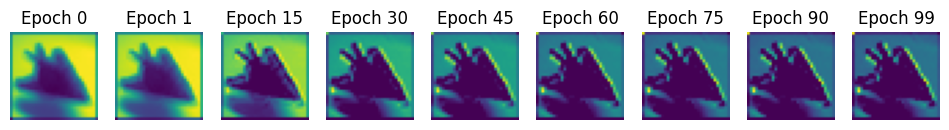

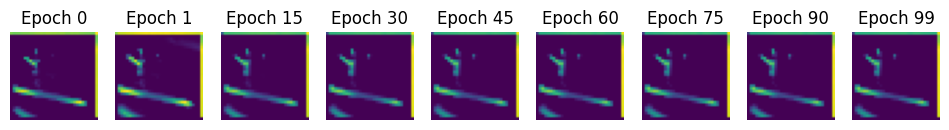

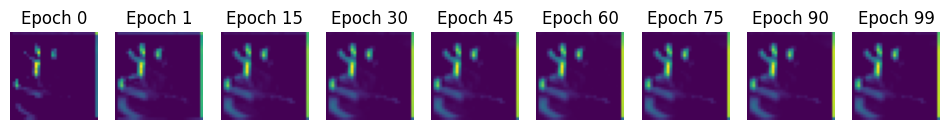

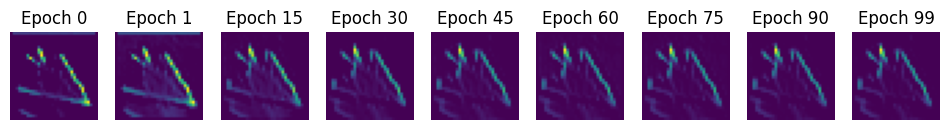

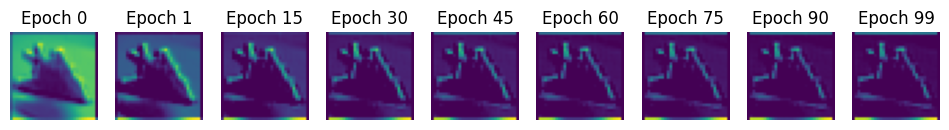

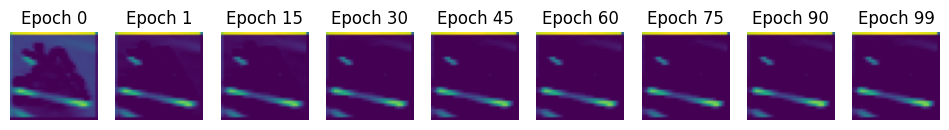

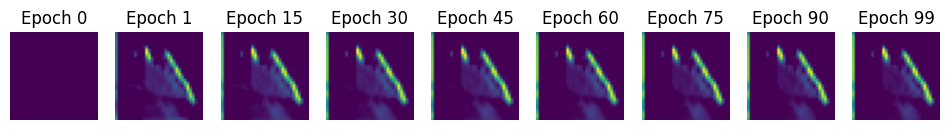

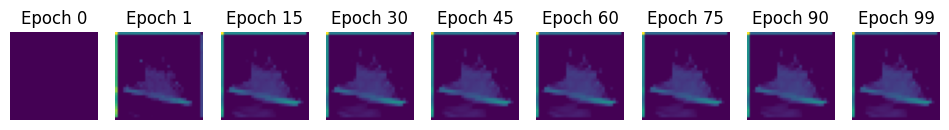

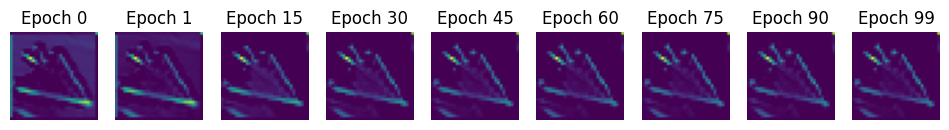

In [21]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i

    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))


    for ax, epoch in zip(axes, epochs):

        fmap = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(fmap,cmap="viridis")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [24]:
import torch.nn.functional as F 
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.4253)
tensor(0.9532)


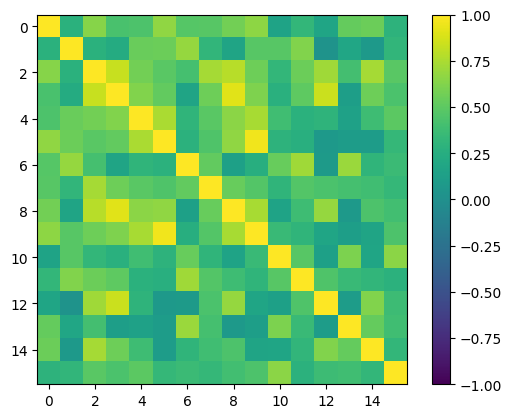

In [25]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

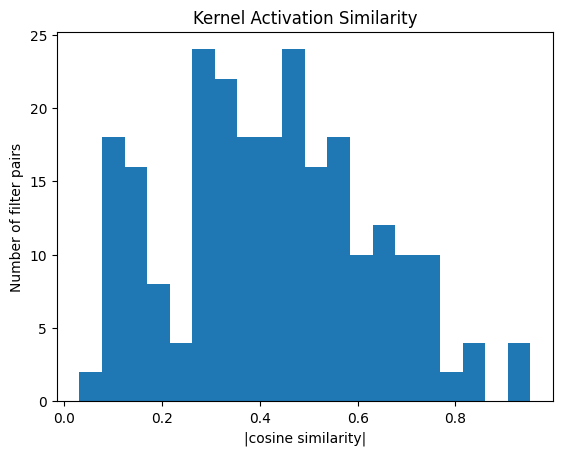

In [26]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

In [28]:
weights = feature_history[99]["kernel_weights"]

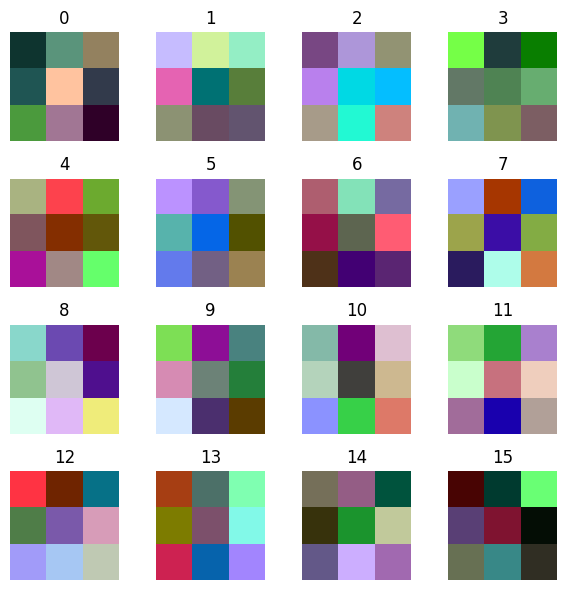

In [29]:
weights = weights.detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i]  # (3, 3, 3)

    # Normalise each kernel for visualisation
    kernel_min = kernel.min()
    kernel_max = kernel.max()

    kernel = (kernel - kernel_min) / (kernel_max - kernel_min + 1e-8)

    ax.imshow(kernel.permute(1, 2, 0))
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
conv_weights = model.conv1.weight.flatten(1)

conv_weights = F.normalize(conv_weights, dim=1)

similarity_matrix = conv_weights @ conv_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=conv_weights.device)


mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")


Mean abs filter cosine similarity: 0.1881
Mean filter cosine similarity: -0.0055
Maximum filter similarity: 0.5211
Minimum filter similarity: -0.5261


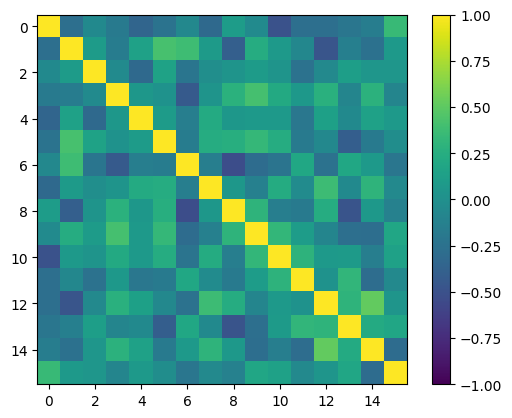

In [31]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

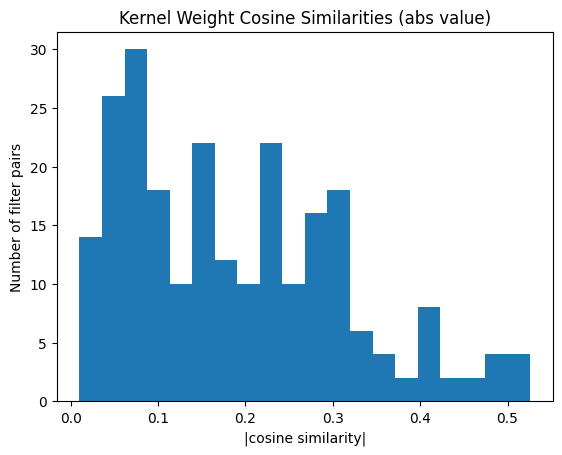

In [32]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Convolutional Autoencoder Method (that is the equivalent networked encoder)

## Original version

In [14]:
from src.experiments import cnn_experiments
from src.models import conv_autoencoder

In [ ]:
#count how many params of the model...

device = torch.device('cpu')

model = conv_autoencoder.CNN_AE(
        input_dims=32,
        in_channels=3,
        pool_kernel_size=2,
        pool_stride=2,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        classes=10,
        bias=True
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 3, 3, 3) -> 432
decoder.weight       (16, 3, 3, 3) -> 432
fc.weight            (10, 4096) -> 40960
fc.bias              (10,) -> 10
41834


In [17]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100
    
    model, training_history,feature_hist, elapsed = cnn_experiments.train_ae_cnn(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=True,
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0227
Epoch [1/1], Training Loss: 1.7997, Training Accuracy: 36.55
peak memory from train : 91.91015625
memory now reset and is: 17.5732421875 MB
time elapsed: 2.0552196300000105
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.0328
Epoch [1/100], Training Loss: 1.8260, Training Accuracy: 35.70
Epoch [2/100], Encoder Loss: 0.0026
Epoch [2/100], Training Loss: 1.6495, Training Accuracy: 42.04
Epoch [3/100], Encoder Loss: 0.0018
Epoch [3/100], Training Loss: 1.6440, Training Accuracy: 42.33
Epoch [4/100], Encoder Loss: 0.0015
Epoch [4/100], Training Loss: 1.6377, Training Accuracy: 42.53
Epoch [5/100], Encoder Loss: 0.0012
Epoch [5/100], Training Loss: 1.6184, Training Accuracy: 43.95
Epoch [6/100], Encoder Loss: 0.0010
Epoch [6/100], Training Loss: 1.6128, Training Accuracy: 43.68
Epoch [7/100], Encoder Loss: 0.0010
Epoch [7/100], Training Loss: 1.5895, Training Accuracy: 44.88
Epoch [8/100], Encoder Loss: 0.0009
Epoch 

average over last 10 epochs for seed=1

In [18]:
51.90 + 50.90 + 51.58+ 51.97+51.19+52.06+51.28+51.68+49.94+51.93

514.43

In [18]:

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [20]:
epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})


epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_init_cifar_10_epoch_results.csv",
    index=False,
)

# Loss and Accuracy

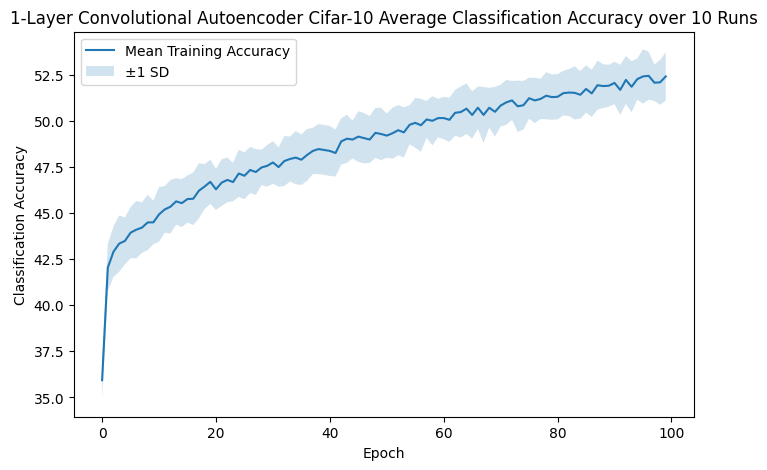

In [21]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Average Classification Accuracy over 10 Runs")
plt.show()

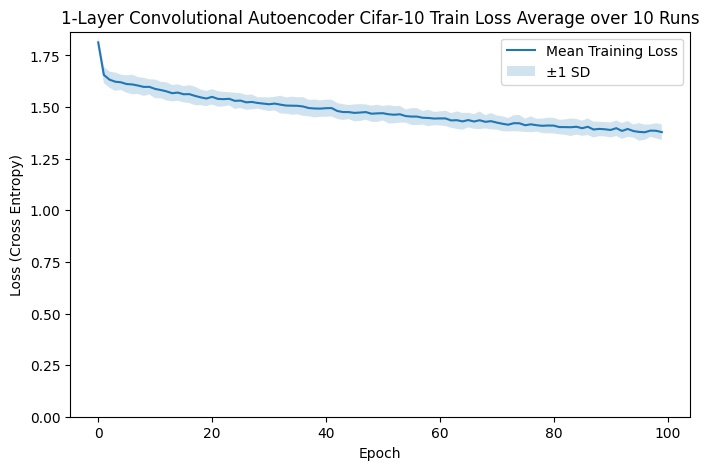

In [22]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom =0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Train Loss Average over 10 Runs")
plt.show()

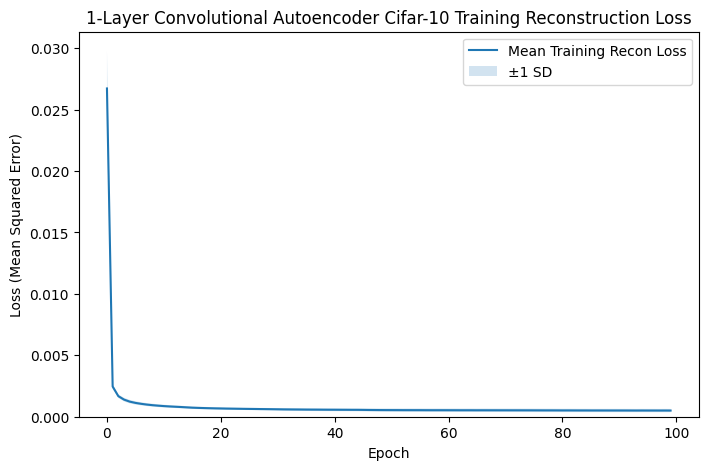

In [23]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Recon Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Training Reconstruction Loss")
plt.show()

# Memory and Overhead

In [24]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 91.2333984375
All peak memories (including the warm up run):


[91.91015625,
 91.2333984375,
 91.2333984375,
 91.2333984375,
 91.2333984375,
 91.2333984375,
 91.2333984375,
 91.2333984375,
 91.2333984375,
 91.2333984375,
 91.2333984375]

In [25]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 138.9266914622999 
All training times for the 100 epochs over the 10 runs:


array([139.3768954 , 139.9368972 , 139.87436577, 139.53747953,
       139.54493924, 138.91137569, 137.14998283, 138.04529329,
       139.22480562, 137.66488004])

# Previously found optimal version (remove autoencoder bias and weight tie)

In [15]:
from src.models import weight_tied_conv_autoencoder

In [17]:
#count how many params of the model...


device = torch.device('cpu')

model = weight_tied_conv_autoencoder.CNN_AE(
        input_dims=32,
        in_channels=3,
        pool_kernel_size=2,
        pool_stride=2,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        classes=10,
        bias=False
    ).to(device)


for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

encoder.weight       (16, 3, 3, 3) -> 432
fc.weight            (10, 4096) -> 40960
fc.bias              (10,) -> 10
41402


In [21]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100
    
    model, training_history,feature_hist, elapsed = cnn_experiments.train_ae_cnn_weight_tied(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0716
Epoch [1/1], Training Loss: 1.7953, Training Accuracy: 38.09
peak memory from train : 91.21826171875
memory now reset and is: 17.5673828125 MB
time elapsed: 1.594324780999841
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.0712
Epoch [1/100], Training Loss: 1.7907, Training Accuracy: 38.38
Epoch [2/100], Encoder Loss: 0.0421
Epoch [2/100], Training Loss: 1.5560, Training Accuracy: 47.04
Epoch [3/100], Encoder Loss: 0.0404
Epoch [3/100], Training Loss: 1.4658, Training Accuracy: 49.88
Epoch [4/100], Encoder Loss: 0.0394
Epoch [4/100], Training Loss: 1.3961, Training Accuracy: 52.12
Epoch [5/100], Encoder Loss: 0.0389
Epoch [5/100], Training Loss: 1.3420, Training Accuracy: 54.51
Epoch [6/100], Encoder Loss: 0.0386
Epoch [6/100], Training Loss: 1.3062, Training Accuracy: 55.89
Epoch [7/100], Encoder Loss: 0.0383
Epoch [7/100], Training Loss: 1.2836, Training Accuracy: 56.68
Epoch [8/100], Encoder Loss: 0.0381
Epoc

average over final 10 epochs for seed=1

In [19]:
67.98+68.23+68.21+68.19+67.85+67.85+68.15+67.82+67.73+67.74

679.75

In [22]:

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})


epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_cifar_10_epoch_results.csv",
    index=False,
)

# Loss and Accuracy

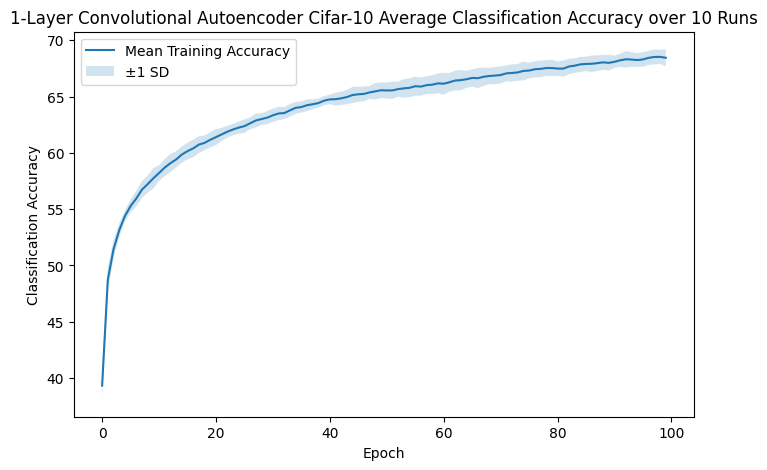

In [28]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Average Classification Accuracy over 10 Runs")
plt.show()

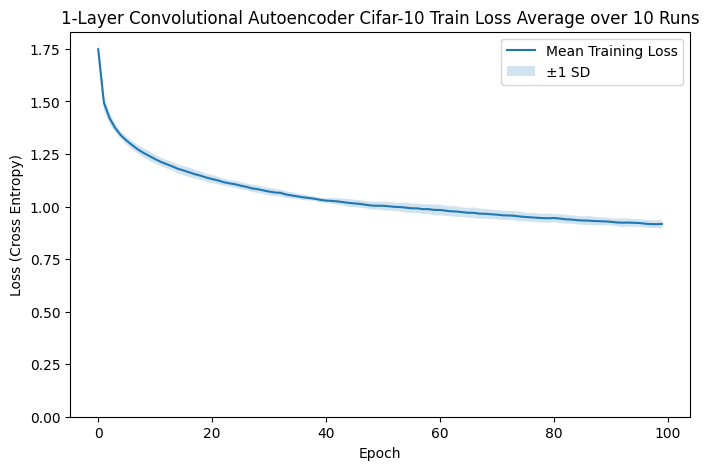

In [31]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom =0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Train Loss Average over 10 Runs")
plt.show()

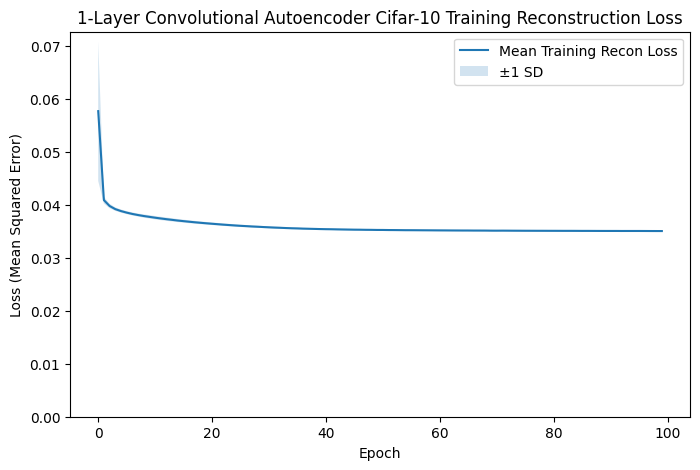

In [33]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Recon Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Training Reconstruction Loss")
plt.show()

# Compressing the feature representations to 16x16

In [17]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): # just 1 run
    #run training and evaluation

    if seed==0:
        n_epochs=1
    else:
        n_epochs=100


    print(f"model run: {seed}")


    model, training_history, elapsed = cnn_experiments.train_no_pool_ae_cnn_weight_tied(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=2,
        padding=1,
        kernel_size=3,
        output_padding=1,
        n_classes=10,
        bias=False,
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0581
Epoch [1/1], Training Loss: 1.8479, Training Accuracy: 35.51
peak memory from train : 86.05810546875
memory now reset and is: 20.72705078125 MB
time elapsed: 2.499300491000099
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.0578
Epoch [1/100], Training Loss: 1.8292, Training Accuracy: 35.86
Epoch [2/100], Encoder Loss: 0.0471
Epoch [2/100], Training Loss: 1.5824, Training Accuracy: 45.17
Epoch [3/100], Encoder Loss: 0.0452
Epoch [3/100], Training Loss: 1.5094, Training Accuracy: 47.80
Epoch [4/100], Encoder Loss: 0.0441
Epoch [4/100], Training Loss: 1.4690, Training Accuracy: 49.32
Epoch [5/100], Encoder Loss: 0.0436
Epoch [5/100], Training Loss: 1.4397, Training Accuracy: 50.48
Epoch [6/100], Encoder Loss: 0.0431
Epoch [6/100], Training Loss: 1.4176, Training Accuracy: 51.34
Epoch [7/100], Encoder Loss: 0.0427
Epoch [7/100], Training Loss: 1.4013, Training Accuracy: 51.86
Epoch [8/100], Encoder Loss: 0.0422
Epo

In [18]:

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


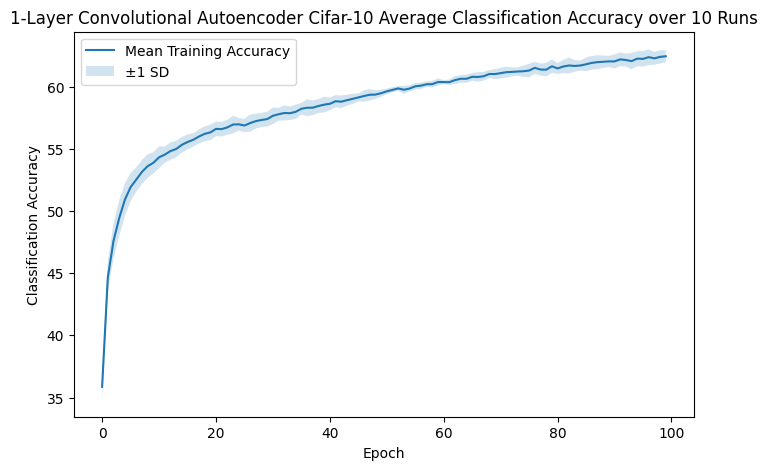

In [19]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Average Classification Accuracy over 10 Runs")
plt.show()

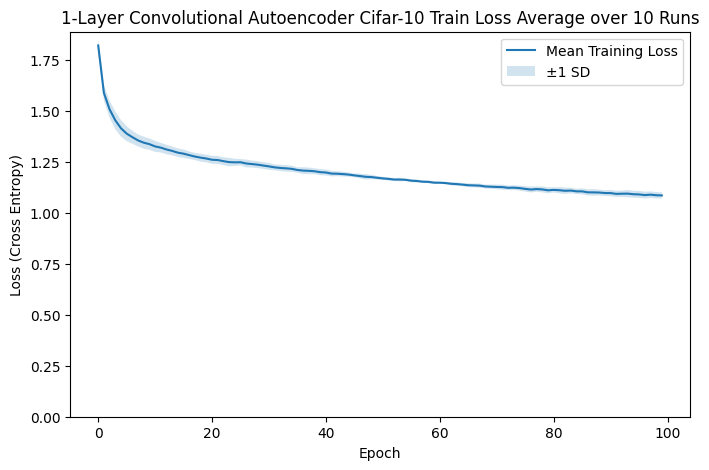

In [20]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom =0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Train Loss Average over 10 Runs")
plt.show()

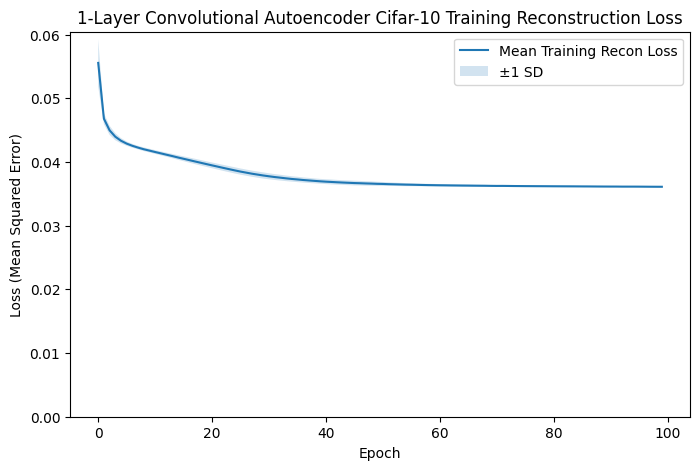

In [21]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Recon Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Training Reconstruction Loss")
plt.show()

# Remove the pooling, keep the 32x32 feature map

In [22]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(11): # just 1 run
    #run training and evaluation

    if seed==0:
        n_epochs=1
    else:
        n_epochs=100


    print(f"model run: {seed}")


    model, training_history, elapsed = cnn_experiments.train_no_pool_ae_cnn_weight_tied(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        output_padding=0,
        n_classes=10,
        bias=False,
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Loss: 0.0716
Epoch [1/1], Training Loss: 1.8821, Training Accuracy: 38.18
peak memory from train : 95.78076171875
memory now reset and is: 19.2548828125 MB
time elapsed: 1.5834004809998987
model run: 1
device is: cuda
Epoch [1/100], Encoder Loss: 0.0712
Epoch [1/100], Training Loss: 1.8582, Training Accuracy: 38.50
Epoch [2/100], Encoder Loss: 0.0421
Epoch [2/100], Training Loss: 1.5643, Training Accuracy: 45.65
Epoch [3/100], Encoder Loss: 0.0404
Epoch [3/100], Training Loss: 1.4827, Training Accuracy: 48.56
Epoch [4/100], Encoder Loss: 0.0394
Epoch [4/100], Training Loss: 1.4045, Training Accuracy: 51.79
Epoch [5/100], Encoder Loss: 0.0389
Epoch [5/100], Training Loss: 1.3460, Training Accuracy: 53.84
Epoch [6/100], Encoder Loss: 0.0386
Epoch [6/100], Training Loss: 1.3118, Training Accuracy: 55.13
Epoch [7/100], Encoder Loss: 0.0383
Epoch [7/100], Training Loss: 1.2850, Training Accuracy: 56.06
Epoch [8/100], Encoder Loss: 0.0381
Epo

In [23]:

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_train_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_train_accuracies[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


In [24]:
epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})


epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/conv_ae_cifar_10_no_pool_28x28maps_epoch_results.csv",
    index=False,
)

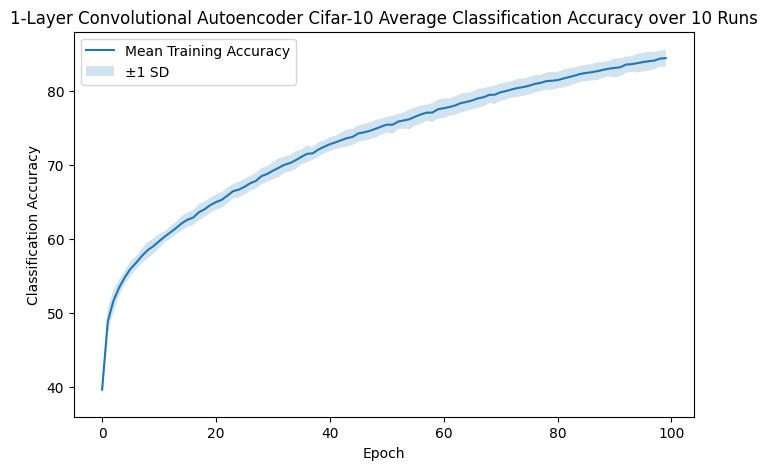

In [25]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Average Classification Accuracy over 10 Runs")
plt.show()

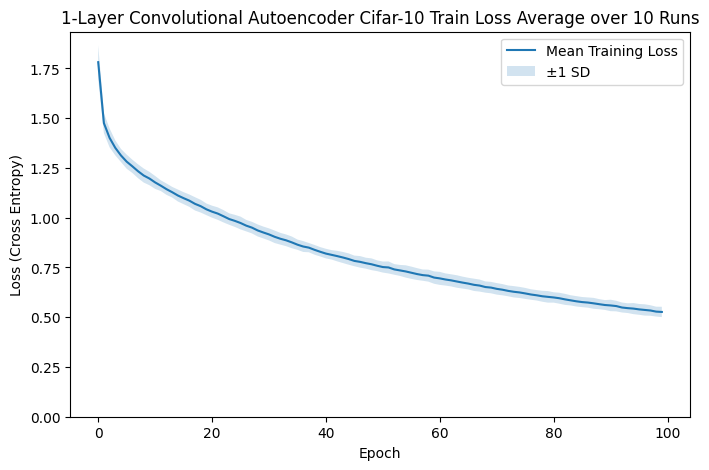

In [26]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom =0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Train Loss Average over 10 Runs")
plt.show()

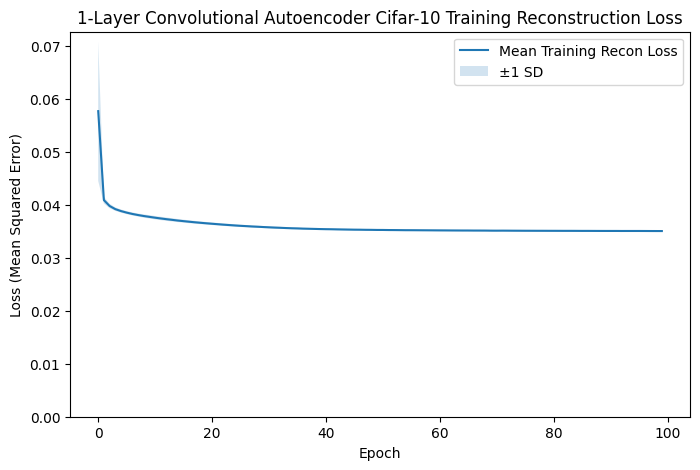

In [27]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Recon Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0)
plt.title("1-Layer Convolutional Autoencoder Cifar-10 Training Reconstruction Loss")
plt.show()

# Inspecting the features of the optimal model with pooling

In [33]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_ae_cnn_weight_tie_get_features(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Loss: 0.0716
Epoch [1/100], Training Loss: 1.7953, Training Accuracy: 38.09
Epoch [2/100], Encoder Loss: 0.0417
Epoch [2/100], Training Loss: 1.4868, Training Accuracy: 48.90
Epoch [3/100], Encoder Loss: 0.0403
Epoch [3/100], Training Loss: 1.4246, Training Accuracy: 51.45
Epoch [4/100], Encoder Loss: 0.0396
Epoch [4/100], Training Loss: 1.3849, Training Accuracy: 52.75
Epoch [5/100], Encoder Loss: 0.0391
Epoch [5/100], Training Loss: 1.3490, Training Accuracy: 54.06
Epoch [6/100], Encoder Loss: 0.0387
Epoch [6/100], Training Loss: 1.3259, Training Accuracy: 54.88
Epoch [7/100], Encoder Loss: 0.0385
Epoch [7/100], Training Loss: 1.3073, Training Accuracy: 55.28
Epoch [8/100], Encoder Loss: 0.0382
Epoch [8/100], Training Loss: 1.2904, Training Accuracy: 55.86
Epoch [9/100], Encoder Loss: 0.0381
Epoch [9/100], Training Loss: 1.2744, Training Accuracy: 56.32
Epoch [10/100], Encoder Loss: 0.0379
Epoch [10/100], Training Loss: 1.2555, Trai

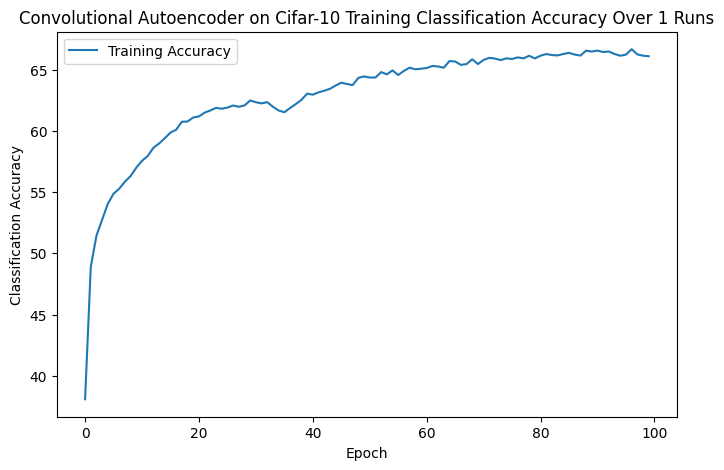

In [ ]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on Cifar-10 Training Classification Accuracy Over 1 Runs")
plt.show()

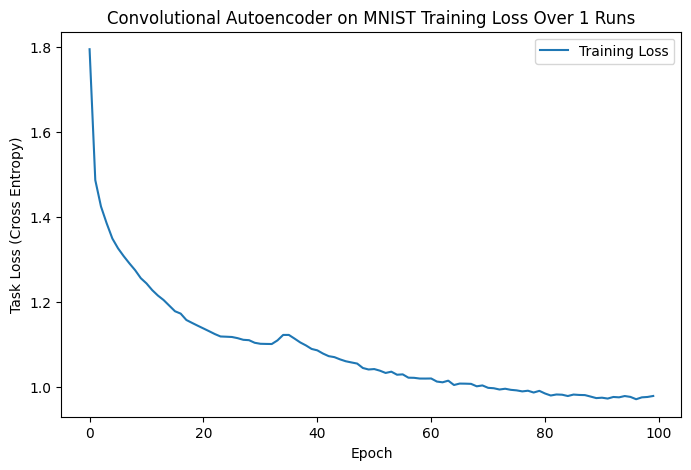

In [37]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Task Loss (Cross Entropy)")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on MNIST Training Loss Over 1 Runs")
plt.show()

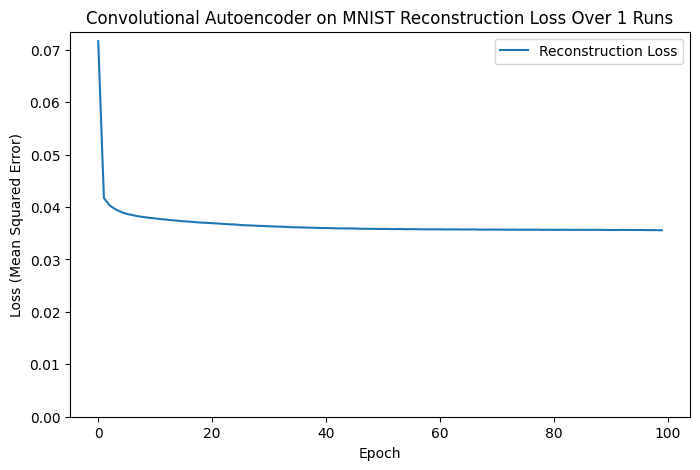

In [41]:
epochs = np.arange(len(training_history["encoder_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["encoder_train_loss"],label="Reconstruction Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0)
plt.title("Convolutional Autoencoder on MNIST Reconstruction Loss Over 1 Runs")
plt.show()

In [43]:
weights =feature_history[99]["encoder_weights"]

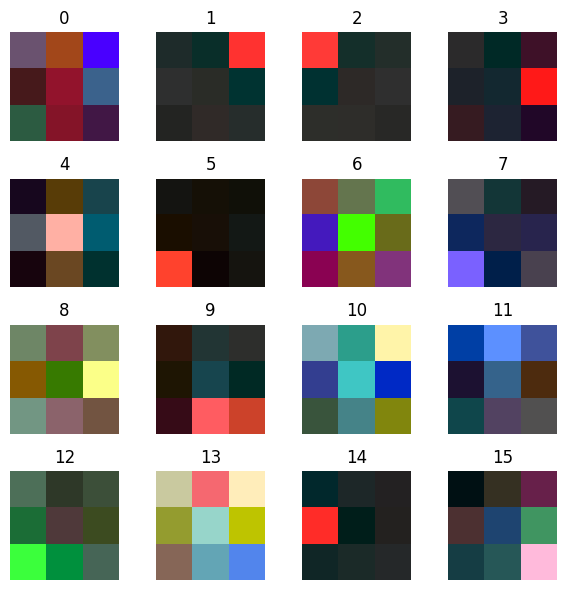

In [44]:
weights = weights.detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i]  # (3, 3, 3)

    # Normalise each kernel for visualisation
    kernel_min = kernel.min()
    kernel_max = kernel.max()

    kernel = (kernel - kernel_min) / (kernel_max - kernel_min + 1e-8)

    ax.imshow(kernel.permute(1, 2, 0))
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [45]:
import torch.nn.functional as F 
encoder_weights = model.encoder.weight.flatten(1)

encoder_weights = F.normalize(encoder_weights, dim=1)

similarity_matrix = encoder_weights @ encoder_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=encoder_weights.device)

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.1219
Mean filter cosine similarity: -0.0355
Maximum filter similarity: 0.4670
Minimum filter similarity: -0.3664


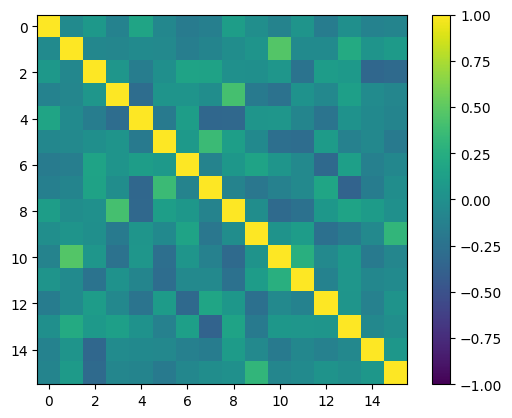

In [46]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

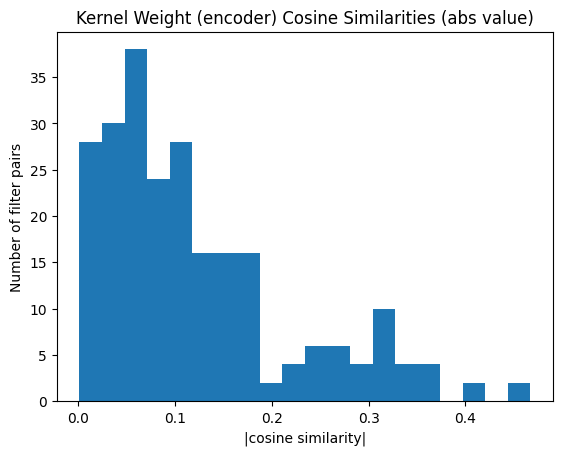

In [47]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight (encoder) Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Features

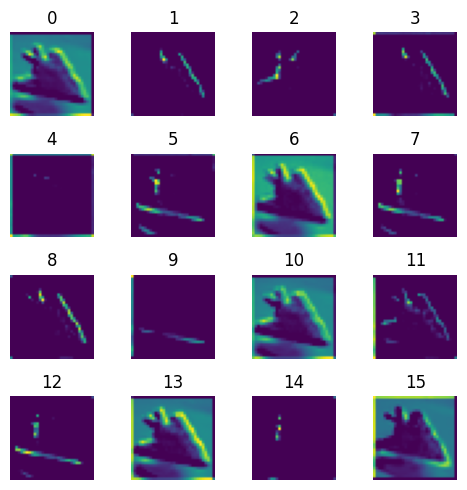

In [48]:
weights = feature_history[99]["maps"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[0,i], cmap="viridis")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

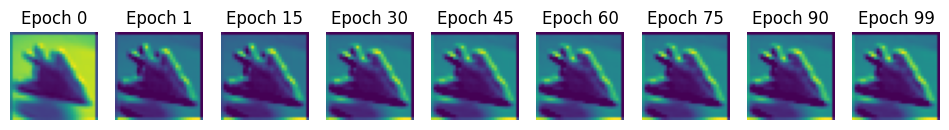

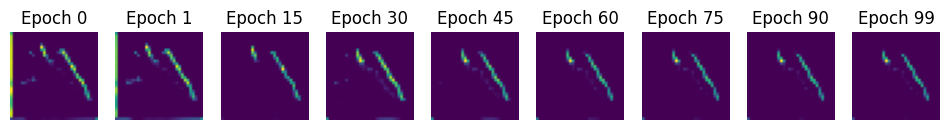

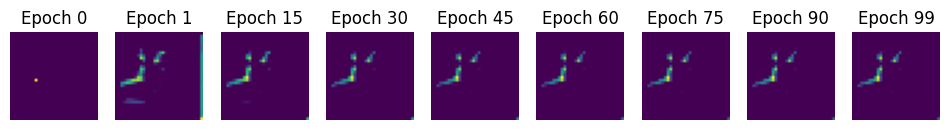

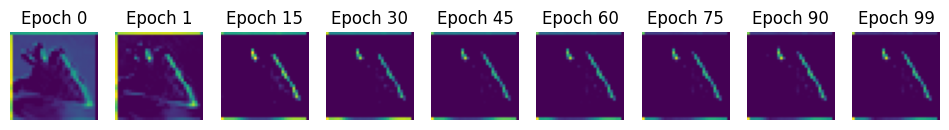

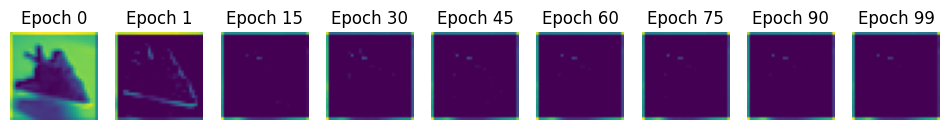

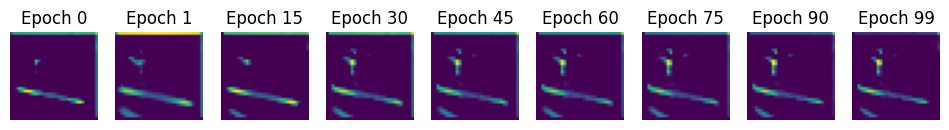

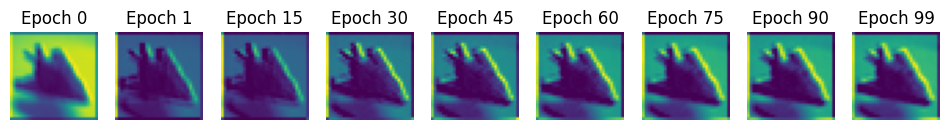

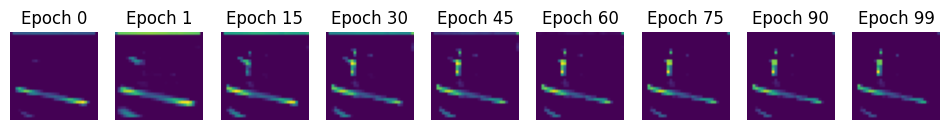

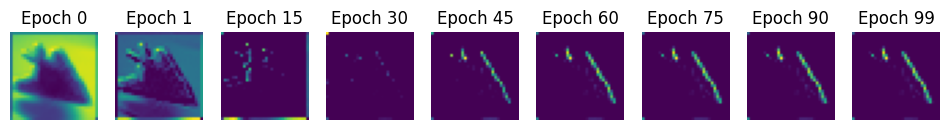

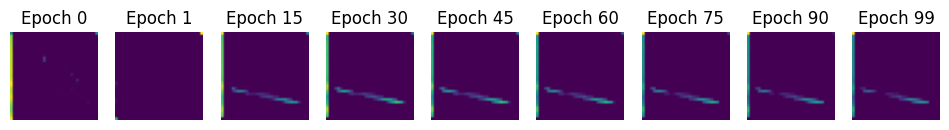

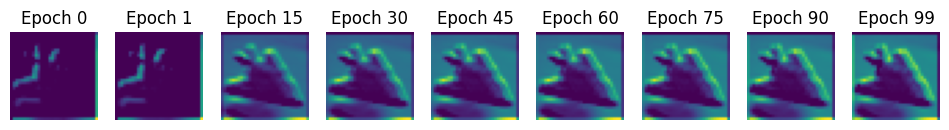

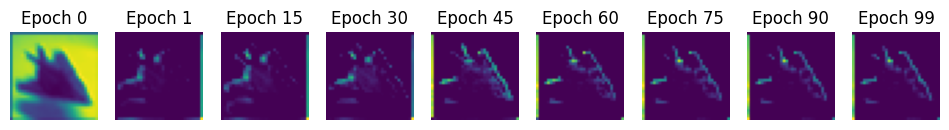

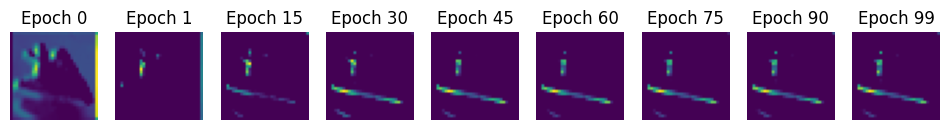

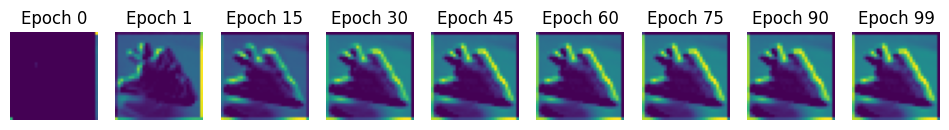

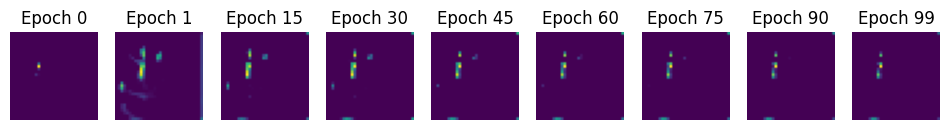

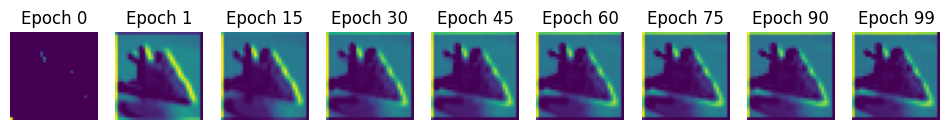

In [51]:
epochs =[0,1,15,30,45,60,75,90,99]

for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [52]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)


mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.3418)
tensor(0.9953)


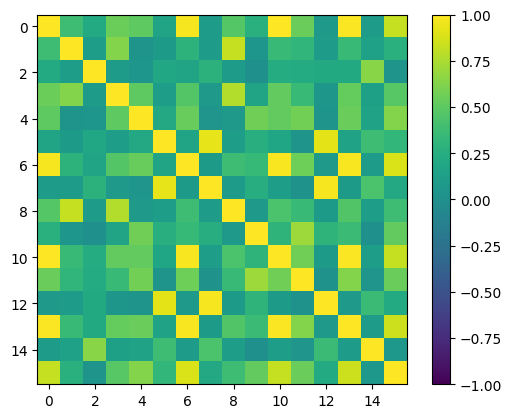

In [53]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

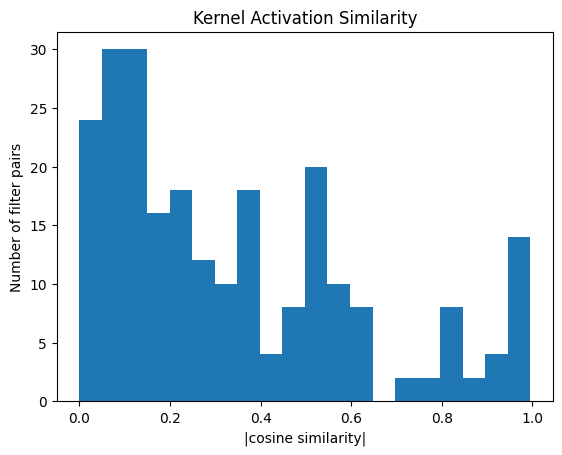

In [54]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Filters as Autoencoders Method

In [13]:
#get model
from src.models import nan_cnn
from src.models import no_pool_weight_share_nan_cnn
from src.models import weight_share_nan_cnn

#get experiment
from src.experiments import nan_cnn_experiment

# Initial results with a single learning rate for autoencoding and classification

In [14]:
#count how many params of the model...

device = torch.device('cpu')

model = nan_cnn.FilterCNN(
        input_dims=32,
        in_channels=3,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,

        bias=True,
        pool_kernel_size=2,
        pool_stride=2,
        classes=10
    ).to(device)



for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

filters.0.encoder.weight (1, 3, 3, 3) -> 27
filters.0.encoder.bias (1,) -> 1
filters.0.decoder.weight (1, 3, 3, 3) -> 27
filters.0.decoder.bias (3,) -> 3
filters.1.encoder.weight (1, 3, 3, 3) -> 27
filters.1.encoder.bias (1,) -> 1
filters.1.decoder.weight (1, 3, 3, 3) -> 27
filters.1.decoder.bias (3,) -> 3
filters.2.encoder.weight (1, 3, 3, 3) -> 27
filters.2.encoder.bias (1,) -> 1
filters.2.decoder.weight (1, 3, 3, 3) -> 27
filters.2.decoder.bias (3,) -> 3
filters.3.encoder.weight (1, 3, 3, 3) -> 27
filters.3.encoder.bias (1,) -> 1
filters.3.decoder.weight (1, 3, 3, 3) -> 27
filters.3.decoder.bias (3,) -> 3
filters.4.encoder.weight (1, 3, 3, 3) -> 27
filters.4.encoder.bias (1,) -> 1
filters.4.decoder.weight (1, 3, 3, 3) -> 27
filters.4.decoder.bias (3,) -> 3
filters.5.encoder.weight (1, 3, 3, 3) -> 27
filters.5.encoder.bias (1,) -> 1
filters.5.decoder.weight (1, 3, 3, 3) -> 27
filters.5.decoder.bias (3,) -> 3
filters.6.encoder.weight (1, 3, 3, 3) -> 27
filters.6.encoder.bias (1,) -> 1

In [14]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(1): # just 1 run

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = nan_cnn_experiment.train_nan_cnn_show_features(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        learning_rate=0.001,
        dual_lr=False,
        #classifier_lr=0.001,
        #ae_lr=0.00001,

        bias=True,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.0609
Epoch [1/100], Task Training Loss: 1.8584, Accuracy: 35.63%
Epoch [2/100], Encoder Training Loss: 0.0428
Epoch [2/100], Task Training Loss: 1.6394, Accuracy: 42.81%
Epoch [3/100], Encoder Training Loss: 0.0292
Epoch [3/100], Task Training Loss: 1.6335, Accuracy: 43.22%
Epoch [4/100], Encoder Training Loss: 0.0224
Epoch [4/100], Task Training Loss: 1.6703, Accuracy: 42.24%
Epoch [5/100], Encoder Training Loss: 0.0173
Epoch [5/100], Task Training Loss: 1.6948, Accuracy: 41.44%
Epoch [6/100], Encoder Training Loss: 0.0140
Epoch [6/100], Task Training Loss: 1.7003, Accuracy: 41.37%
Epoch [7/100], Encoder Training Loss: 0.0123
Epoch [7/100], Task Training Loss: 1.7182, Accuracy: 40.38%
Epoch [8/100], Encoder Training Loss: 0.0110
Epoch [8/100], Task Training Loss: 1.7451, Accuracy: 39.49%
Epoch [9/100], Encoder Training Loss: 0.0101
Epoch [9/100], Task Training Loss: 1.7584, Accuracy: 39.33%
Epoch [10/100], Encoder Tr

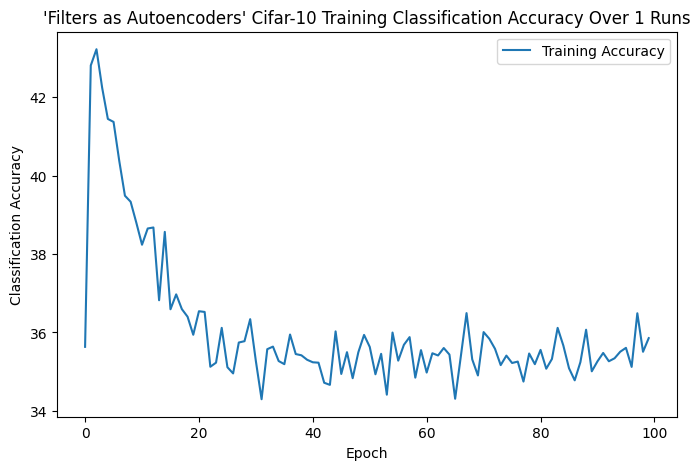

In [15]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' Cifar-10 Training Classification Accuracy Over 1 Runs")
plt.show()

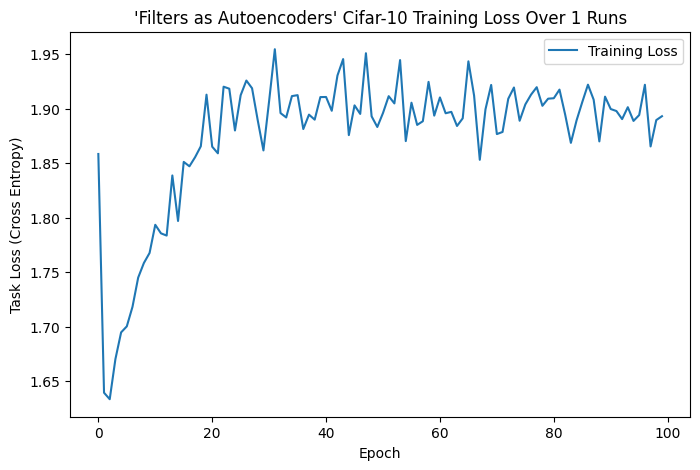

In [16]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Task Loss (Cross Entropy)")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' Cifar-10 Training Loss Over 1 Runs")
plt.show()

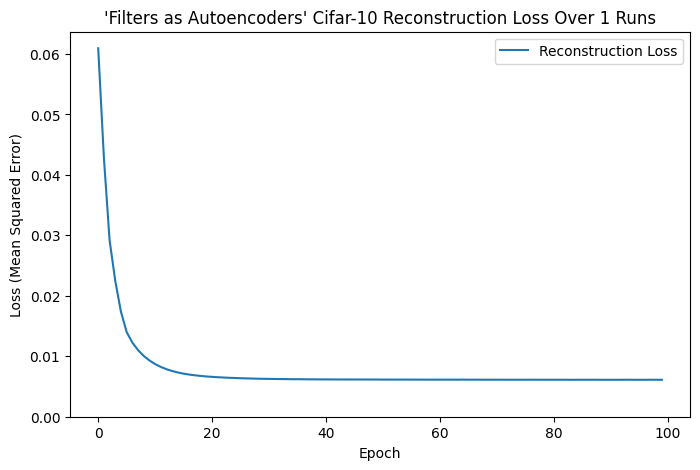

In [17]:
epochs = np.arange(len(training_history["encoder_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["encoder_train_loss"],label="Reconstruction Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0)
plt.title("'Filters as Autoencoders' Cifar-10 Reconstruction Loss Over 1 Runs")
plt.show()

In [18]:
weights =feature_history[99]["encoder_weights"]

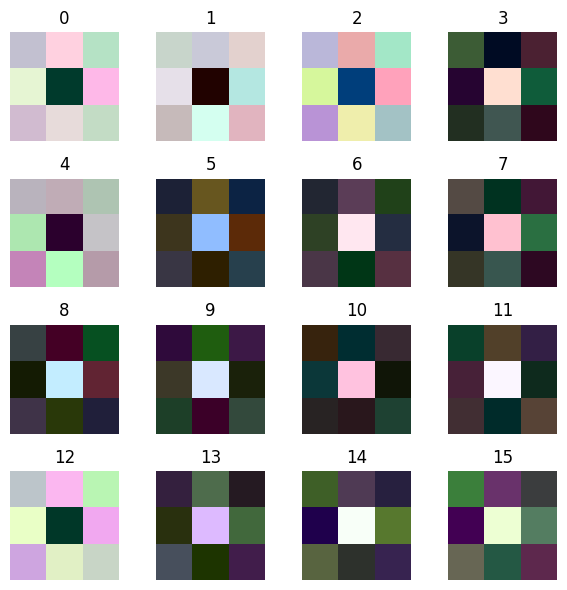

In [19]:
weights = weights.detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i]  # (3, 3, 3)

    # Normalise each kernel for visualisation
    kernel_min = kernel.min()
    kernel_max = kernel.max()

    kernel = (kernel - kernel_min) / (kernel_max - kernel_min + 1e-8)

    ax.imshow(kernel.permute(1, 2, 0))
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
weights

tensor([[[[-4.7603e-02,  1.3572e-01, -8.7568e-02],
          [ 6.1260e-02, -6.3592e-01,  1.3301e-01],
          [-1.8983e-03,  6.4339e-02, -4.3605e-02]],

         [[-5.4848e-02, -5.8338e-04,  5.0024e-02],
          [ 1.0676e-01, -4.5744e-01, -7.7427e-02],
          [-6.7304e-02,  2.7369e-02,  3.1164e-02]],

         [[-4.9454e-03,  4.4893e-02, -3.8783e-02],
          [ 5.4930e-03, -5.0048e-01,  6.6123e-02],
          [-4.3522e-03,  2.5747e-02, -3.9710e-02]]],


        [[[-2.1846e-02, -1.9573e-02,  5.0640e-02],
          [ 5.9050e-02, -4.7208e-01, -7.6573e-02],
          [-2.8436e-02,  9.9326e-03,  4.5830e-02]],

         [[ 1.3353e-02, -2.1418e-02,  2.3039e-03],
          [ 4.2288e-02, -5.5760e-01,  6.0544e-02],
          [-6.1959e-02,  1.2406e-01, -7.6636e-02]],

         [[-1.4771e-02,  2.1138e-02, -7.4840e-03],
          [ 6.5327e-02, -5.6376e-01,  4.3378e-02],
          [-6.0902e-02,  8.4794e-02, -4.6697e-02]]],


        [[[-3.3726e-02,  1.5288e-01, -1.2294e-01],
          [ 7.8

In [22]:
conv_weights = weights.flatten(1)

In [34]:
conv_weights.shape

torch.Size([16, 27])

In [31]:
import torch.nn.functional as F 

In [32]:
#conv_weights = model.conv1.weight.flatten(1)

conv_weights = weights.flatten(1)

conv_weights = F.normalize(conv_weights, dim=1)

similarity_matrix = conv_weights @ conv_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=conv_weights.device)


mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")


Mean abs filter cosine similarity: 0.8569
Mean filter cosine similarity: 0.0780
Maximum filter similarity: 0.9812
Minimum filter similarity: -0.9462


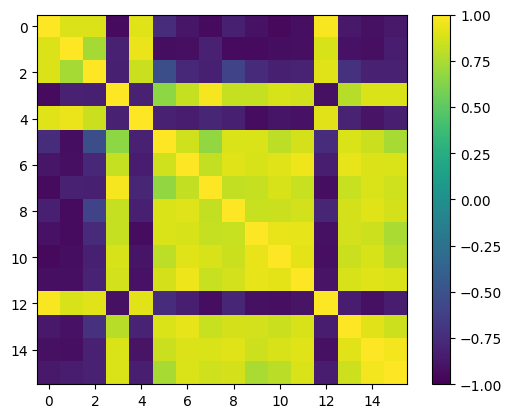

In [33]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

# Separate learning rates with bias and separate autoencoding weights:

In [16]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(1): 
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history, elapsed = nan_cnn_experiment.train_nan_cnn(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        dual_lr= True,
        classifier_lr=0.001,
        #ae_lr=0.0001, # peaks at ~55% and then falls to ~51% (most likely autoencoding cycle is too fast such that redundant kernels optimised for reconstruction hamper classification)
        #ae_lr=0.00001, #peaks at ~65% accuracy (stays around there stabily)
        ae_lr=0.000001, #trying even smaller peaks at ~68%
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=True,
        seed=1 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)


model run: 0
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.0695
Epoch [1/100], Task Training Loss: 1.8468, Accuracy: 35.11%
Epoch [2/100], Encoder Training Loss: 0.0695
Epoch [2/100], Task Training Loss: 1.5982, Accuracy: 44.52%
Epoch [3/100], Encoder Training Loss: 0.0694
Epoch [3/100], Task Training Loss: 1.5034, Accuracy: 48.30%
Epoch [4/100], Encoder Training Loss: 0.0693
Epoch [4/100], Task Training Loss: 1.4604, Accuracy: 49.67%
Epoch [5/100], Encoder Training Loss: 0.0692
Epoch [5/100], Task Training Loss: 1.4208, Accuracy: 51.21%
Epoch [6/100], Encoder Training Loss: 0.0692
Epoch [6/100], Task Training Loss: 1.3996, Accuracy: 51.86%
Epoch [7/100], Encoder Training Loss: 0.0691
Epoch [7/100], Task Training Loss: 1.3635, Accuracy: 53.45%
Epoch [8/100], Encoder Training Loss: 0.0690
Epoch [8/100], Task Training Loss: 1.3542, Accuracy: 53.53%
Epoch [9/100], Encoder Training Loss: 0.0689
Epoch [9/100], Task Training Loss: 1.3386, Accuracy: 54.03%
Epoch [10/100], Encoder Tr

Average over final 10 runs for seed =1

In [17]:
65.48 + 65.31 + 65.06 + 65.13 + 65.21 + 65.12 + 65.02 + 64.93 + 64.90 + 65.26

651.42

# Separate learning rates with weight tying and no biases:

In [ ]:
#count how many params of the model...

device = torch.device('cpu')

model = weight_share_nan_cnn.FilterCNN(
        input_dims=32,
        in_channels=3,
        kernel_size=3,
        stride=1,
        padding=1,
        n_filters=16,
        pool_kernel_size=2,
        pool_stride=2,
        bias=False,
        classes=10
    ).to(device)



for name, param in model.named_parameters():
    print(f"{name:20} {tuple(param.shape)} -> {param.numel()}")

print(sum(p.numel() for p in model.parameters()))

filters.0.encoder.weight (1, 3, 3, 3) -> 27
filters.1.encoder.weight (1, 3, 3, 3) -> 27
filters.2.encoder.weight (1, 3, 3, 3) -> 27
filters.3.encoder.weight (1, 3, 3, 3) -> 27
filters.4.encoder.weight (1, 3, 3, 3) -> 27
filters.5.encoder.weight (1, 3, 3, 3) -> 27
filters.6.encoder.weight (1, 3, 3, 3) -> 27
filters.7.encoder.weight (1, 3, 3, 3) -> 27
filters.8.encoder.weight (1, 3, 3, 3) -> 27
filters.9.encoder.weight (1, 3, 3, 3) -> 27
filters.10.encoder.weight (1, 3, 3, 3) -> 27
filters.11.encoder.weight (1, 3, 3, 3) -> 27
filters.12.encoder.weight (1, 3, 3, 3) -> 27
filters.13.encoder.weight (1, 3, 3, 3) -> 27
filters.14.encoder.weight (1, 3, 3, 3) -> 27
filters.15.encoder.weight (1, 3, 3, 3) -> 27
fc.weight            (10, 4096) -> 40960
fc.bias              (10,) -> 10
41402


In [17]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(11): #10 runs with 1 warm up
    #run training and evaluation

    if seed ==0:
        n_epochs=1
    else:
        n_epochs=100

    print(f"model run: {seed}")


    model, training_history, elapsed = nan_cnn_experiment.train_weight_share_nan_cnn(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        dual_lr= True,
        classifier_lr=0.001,
        #ae_lr=0.0001, # peaks at ~55% and then falls to ~51% (most likely autoencoding cycle is too fast such that redundant kernels optimised for reconstruction hamper classification)
        #ae_lr=0.00001, #peaks at ~65% accuracy (stays around there stabily)
        ae_lr=0.000001, #trying even smaller peaks at ~68%
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Training Loss: 0.0919
Epoch [1/1], Task Training Loss: 1.9079, Accuracy: 33.84%
peak memory from train : 75.64013671875
memory now reset and is: 17.5791015625 MB
time elapsed: 6.70934191500055
model run: 1
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.0749
Epoch [1/100], Task Training Loss: 1.8013, Accuracy: 36.77%
Epoch [2/100], Encoder Training Loss: 0.0748
Epoch [2/100], Task Training Loss: 1.5454, Accuracy: 46.05%
Epoch [3/100], Encoder Training Loss: 0.0748
Epoch [3/100], Task Training Loss: 1.4590, Accuracy: 49.42%
Epoch [4/100], Encoder Training Loss: 0.0747
Epoch [4/100], Task Training Loss: 1.4148, Accuracy: 51.03%
Epoch [5/100], Encoder Training Loss: 0.0747
Epoch [5/100], Task Training Loss: 1.3784, Accuracy: 52.40%
Epoch [6/100], Encoder Training Loss: 0.0746
Epoch [6/100], Task Training Loss: 1.3544, Accuracy: 53.24%
Epoch [7/100], Encoder Training Loss: 0.0746
Epoch [7/100], Task Training Loss: 1.3161, Accuracy: 

average over the final 10 runs for seed =1

In [3]:
68.27 + 68.17 + 67.71 + 67.67 + 67.81 + 68.00 + 67.79 + 68.15 + 67.55 + 68.23

679.35

In [4]:
679.35/10

67.935

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_task_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/faae_optimal_cifar_10_epoch_results.csv",
    index=False,
)

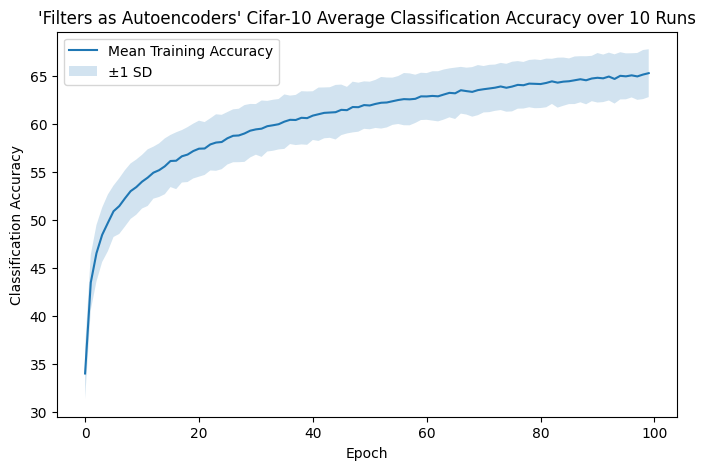

In [20]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' Cifar-10 Average Classification Accuracy over 10 Runs")
plt.show()

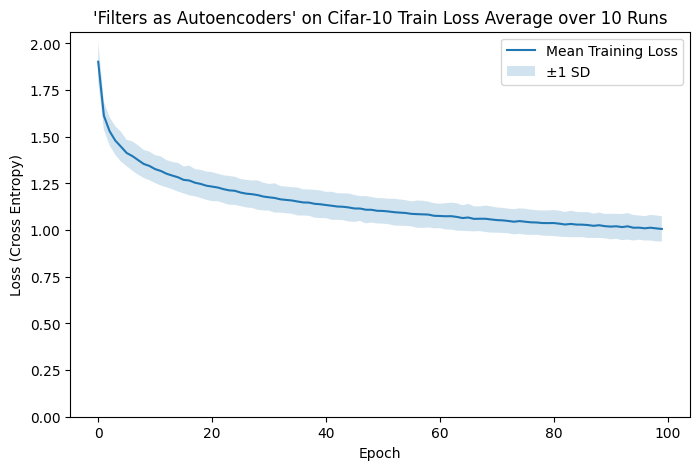

In [23]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom=0)
plt.title("'Filters as Autoencoders' on Cifar-10 Train Loss Average over 10 Runs")
plt.show()

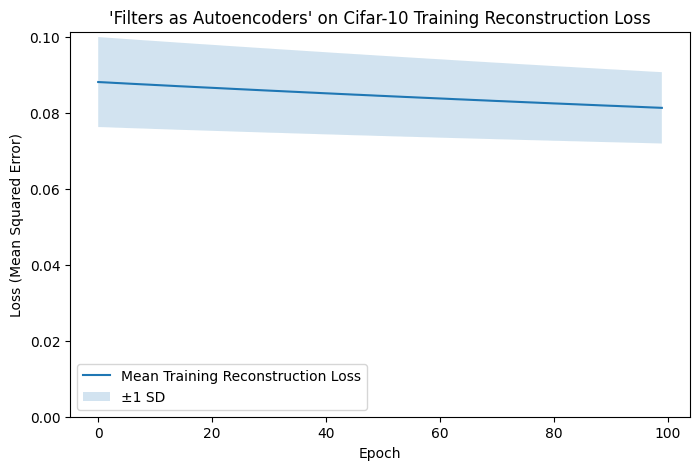

In [24]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Reconstruction Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0)
plt.title("'Filters as Autoencoders' on Cifar-10 Training Reconstruction Loss")
plt.show()

In [25]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 75.96923828125
All peak memories (including the warm up run):


[75.64013671875,
 75.96923828125,
 75.96923828125,
 75.96923828125,
 75.96923828125,
 75.96923828125,
 75.96923828125,
 75.96923828125,
 75.96923828125,
 75.96923828125,
 75.96923828125]

In [26]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 623.1443810228999 
All training times for the 100 epochs over the 10 runs:


array([624.09597167, 618.97998633, 621.86893316, 624.26070198,
       626.58245807, 623.02888524, 626.39922302, 627.35336231,
       619.17523862, 619.69904983])

In [27]:
print(f"Max accuracy: {epoch_df["mean_accuracy"].max()}") #that is, out of the 10 runs, take the average every epoch, then take the max
print(f"Max accuracy std: {epoch_df["std_accuracy"].max()}")

print(f"Min Loss: {epoch_df["task_mean_loss"].min()}")
print(f"Max Loss std: {epoch_df["task_std_loss"].max()}")

print(f"Min Encoder Loss: {epoch_df["encoder_mean_loss"].min()} (to 10 dp: {epoch_df["encoder_mean_loss"].min():.10f})")
print(f"Max Encoder Loss std: {epoch_df["encoder_std_loss"].min()} (to 10 dp: {epoch_df["encoder_std_loss"].min():.10f})")

Max accuracy: 65.2826
Max accuracy std: 2.957930959302465
Min Loss: 1.0062217934703341
Max Loss std: 0.10725641798116704
Min Encoder Loss: 0.08130353927952047 (to 10 dp: 0.0813035393)
Max Encoder Loss std: 0.009389509024113604 (to 10 dp: 0.0093895090)


# Inspecting the features

In [31]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(1): #10 runs with 1 warm up
    #run training and evaluation



    model, training_history,feature_history, elapsed = nan_cnn_experiment.train_nan_cnn_weight_share_show_features(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        dual_lr= True,
        classifier_lr=0.001,
        #ae_lr=0.0001, # peaks at ~55% and then falls to ~51% (most likely autoencoding cycle is too fast such that redundant kernels optimised for reconstruction hamper classification)
        #ae_lr=0.00001, #peaks at ~65% accuracy (stays around there stabily)
        ae_lr=0.000001, #trying even smaller peaks at ~68%
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        pool_stride=2,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

device is: cuda
Epoch [1/100], Encoder Training Loss: 0.0919
Epoch [1/100], Task Training Loss: 1.9079, Accuracy: 33.84%
Epoch [2/100], Encoder Training Loss: 0.0918
Epoch [2/100], Task Training Loss: 1.6276, Accuracy: 42.46%
Epoch [3/100], Encoder Training Loss: 0.0917
Epoch [3/100], Task Training Loss: 1.5593, Accuracy: 45.29%
Epoch [4/100], Encoder Training Loss: 0.0916
Epoch [4/100], Task Training Loss: 1.5095, Accuracy: 47.05%
Epoch [5/100], Encoder Training Loss: 0.0915
Epoch [5/100], Task Training Loss: 1.4803, Accuracy: 48.34%
Epoch [6/100], Encoder Training Loss: 0.0914
Epoch [6/100], Task Training Loss: 1.4455, Accuracy: 49.86%
Epoch [7/100], Encoder Training Loss: 0.0913
Epoch [7/100], Task Training Loss: 1.4321, Accuracy: 50.09%
Epoch [8/100], Encoder Training Loss: 0.0912
Epoch [8/100], Task Training Loss: 1.4244, Accuracy: 50.22%
Epoch [9/100], Encoder Training Loss: 0.0911
Epoch [9/100], Task Training Loss: 1.4086, Accuracy: 50.92%
Epoch [10/100], Encoder Training Loss: 

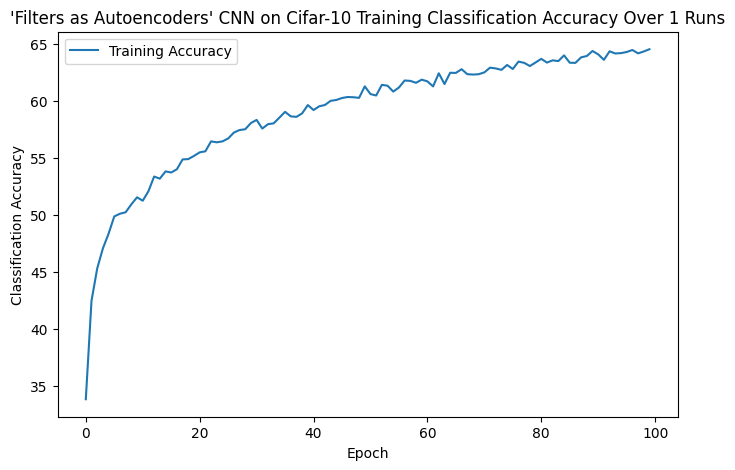

In [32]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on Cifar-10 Training Classification Accuracy Over 1 Runs")
plt.show()

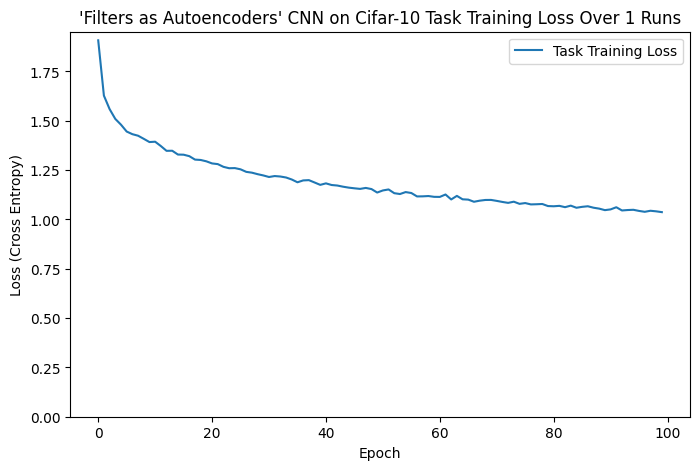

In [37]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Task Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(bottom=0)
plt.title("'Filters as Autoencoders' CNN on Cifar-10 Task Training Loss Over 1 Runs")
plt.show()

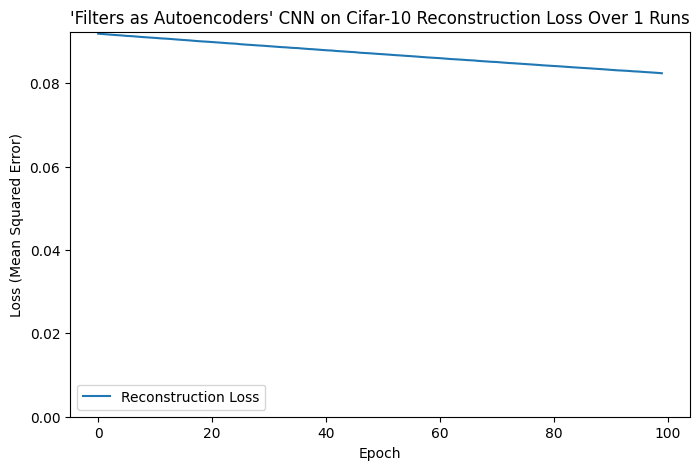

In [36]:
epochs = np.arange(len(training_history["encoder_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["encoder_train_loss"],label="Reconstruction Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom =0)
plt.title("'Filters as Autoencoders' CNN on Cifar-10 Reconstruction Loss Over 1 Runs")
plt.show()

In [52]:
weights = feature_history[99]["encoder_weights"]

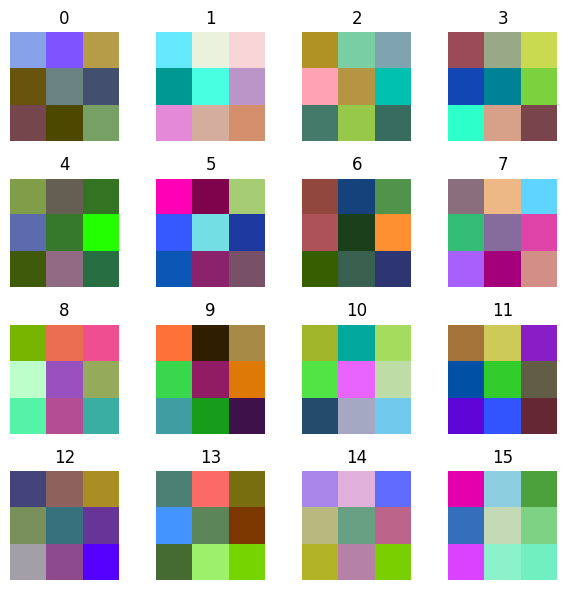

In [ ]:
weights = weights.detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i]  # (3, 3, 3)

    # Normalise each kernel for visualisation
    kernel_min = kernel.min()
    kernel_max = kernel.max()

    kernel = (kernel - kernel_min) / (kernel_max - kernel_min + 1e-8)

    ax.imshow(kernel.permute(1, 2, 0))
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

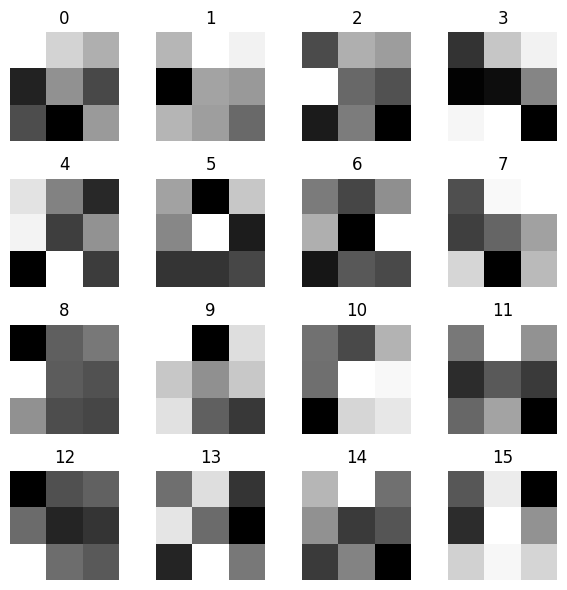

In [48]:
weights = weights.detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):

    kernel = weights[i]   # (3, 3, 3)

    # Collapse RGB channels to one visualisation
    kernel = kernel.mean(dim=0)

    ax.imshow(kernel, cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [55]:
import torch.nn.functional as F 
weights = torch.stack([
    F.normalize(f.encoder.weight.view(-1), dim=0)
    for f in model.filters
])

similarity_matrix = weights @ weights.T

mask = ~torch.eye(16, dtype=torch.bool, device="cuda")

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.1572
Mean filter cosine similarity: -0.0022
Maximum filter similarity: 0.3794
Minimum filter similarity: -0.4709


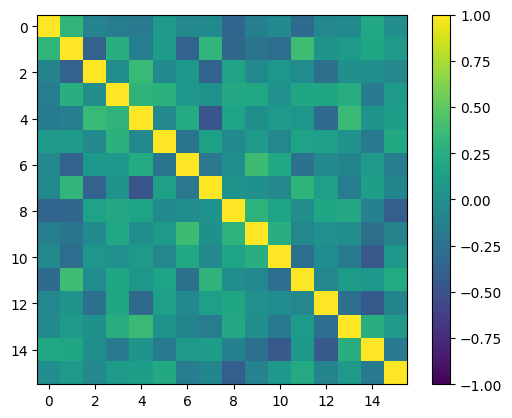

In [56]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

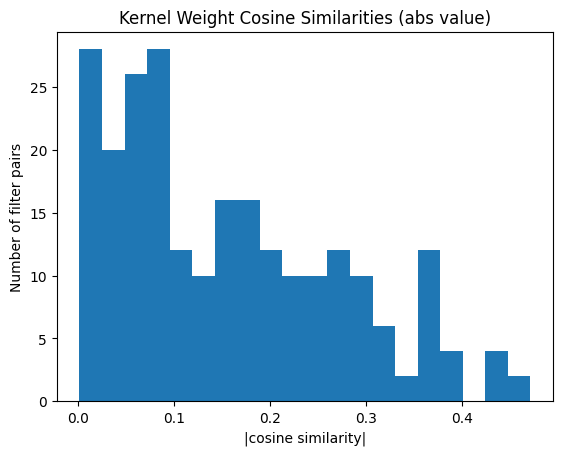

In [57]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Features

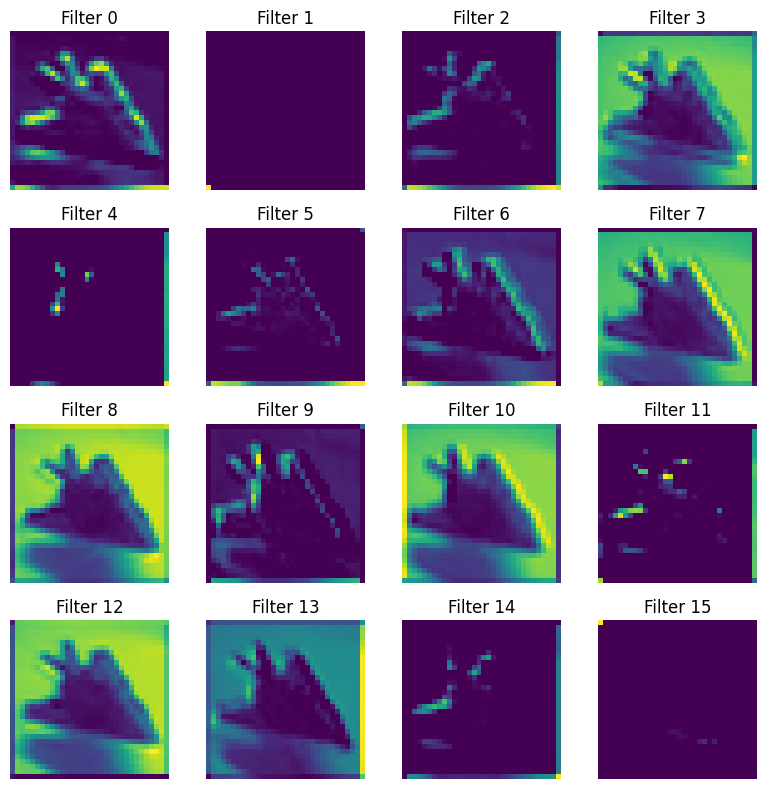

In [58]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

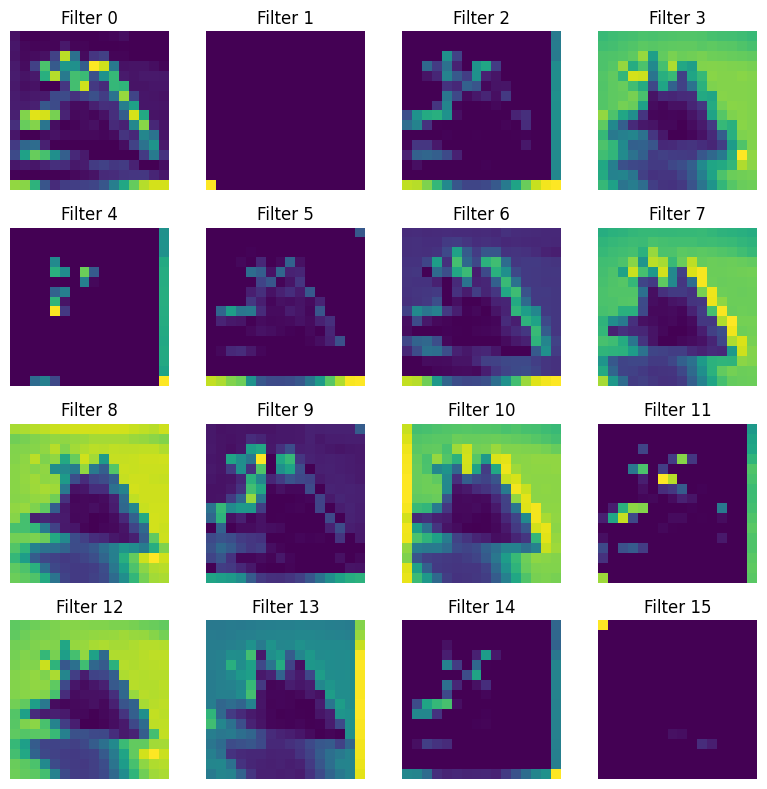

In [60]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["pooled_maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

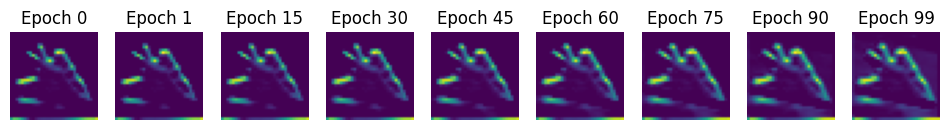

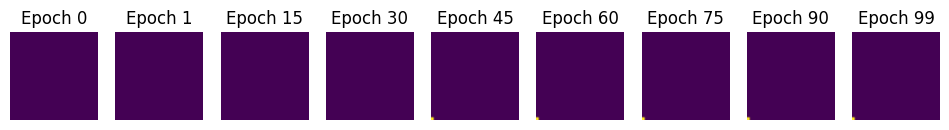

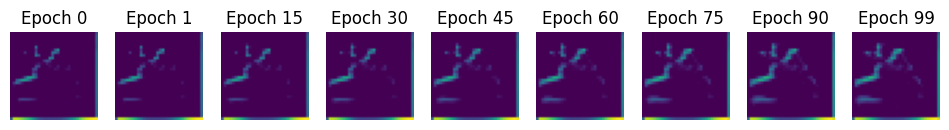

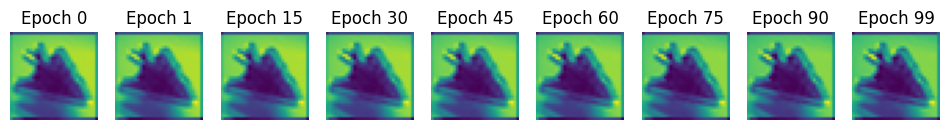

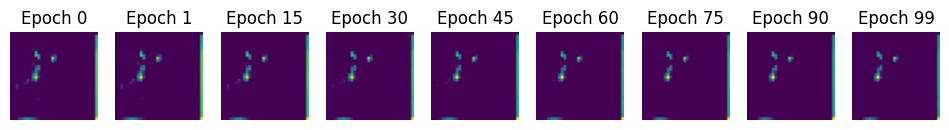

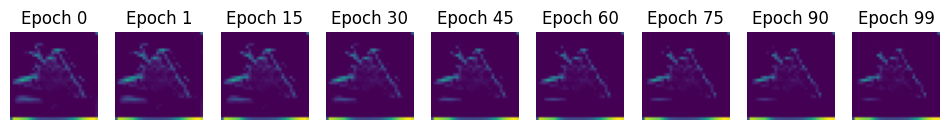

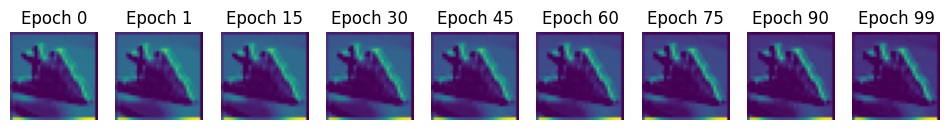

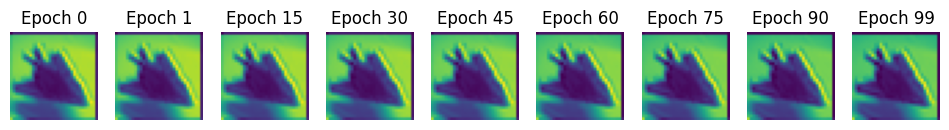

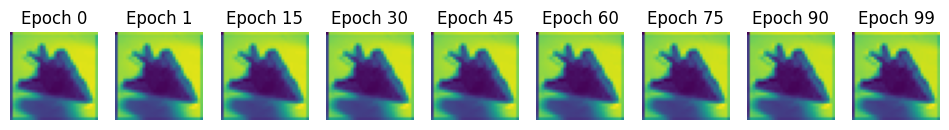

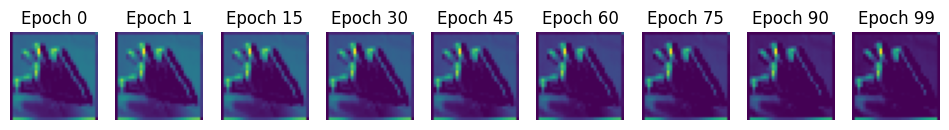

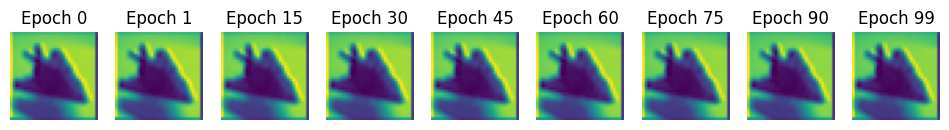

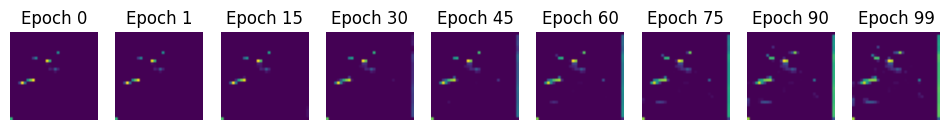

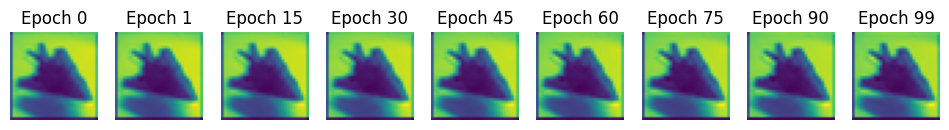

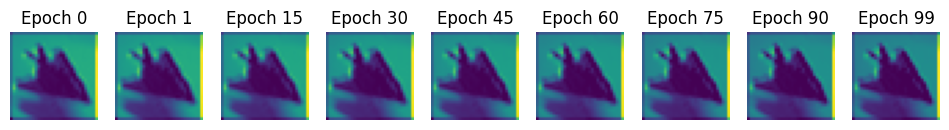

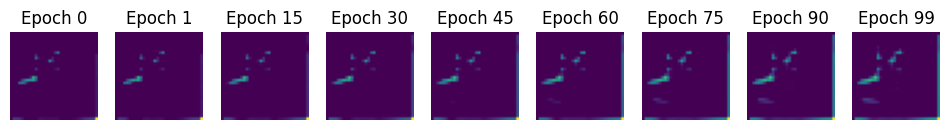

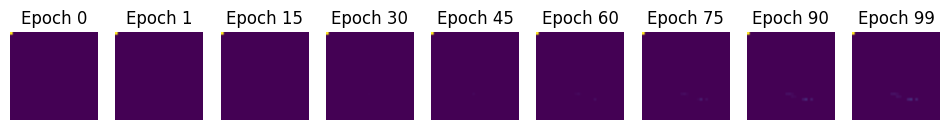

In [61]:
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [62]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.4730)
tensor(0.9933)


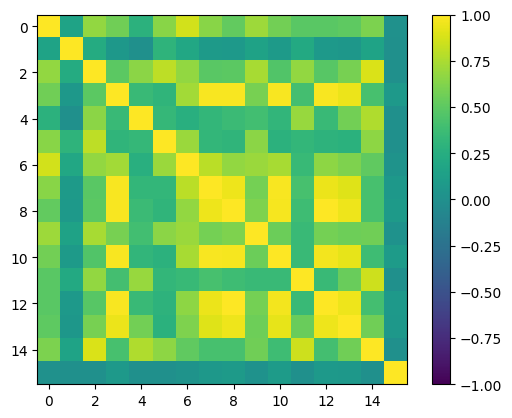

In [63]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

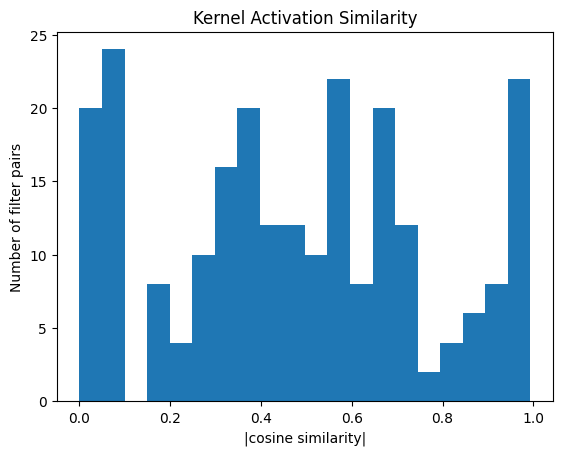

In [64]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Training the pooled version:

In [ ]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_task_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()

In [ ]:

epochs = np.arange(1, len(task_mean_loss)+1)

epoch_df = pd.DataFrame({
    "epoch": epochs,
    "task_mean_loss": task_mean_loss,
    "task_std_loss": task_std_loss,
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "encoder_mean_loss": encoder_mean_loss,
    "encoder_std_loss" : encoder_std_loss
})

epoch_df.to_csv(
    "/content/drive/MyDrive/research_jobs/faae_optimal_cifar_10_epoch_results.csv",
    index=False,
)

In [ ]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

In [ ]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Task Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("'Filters as Autoencoders' CNN on MNIST Task Training Loss Over 10 Runs")
plt.show()

In [ ]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Recon Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom=0, top=0.3)
plt.title("'Filters as Autoencoders' CNN on MNIST Training Reconstruction Loss")
plt.show()

# Memory and Runtime

In [ ]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

In [ ]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

# Test the same model but with 16x16 compressed feature maps

In [17]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(2): 
    #run training and evaluation

    print(f"model run: {seed}")

    
    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100

    model, training_history, elapsed = nan_cnn_experiment.train_parallel_schedule_no_pool_weight_share(
        cifar_train_tensor,
        input_dims=32,
        in_channels=3,
        dual_lr= True,
        classifier_lr=0.001,
        ae_lr=0.000001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=2,
        padding=1,
        kernel_size=3,
        output_padding=1,
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Training Loss: 0.0735
Epoch [1/1], Task Training Loss: 1.9052, Accuracy: 33.12%
peak memory from train : 40.84423828125
memory now reset and is: 17.5791015625 MB
time elapsed: 5.331048843999952
model run: 1
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.0705
Epoch [1/100], Task Training Loss: 1.8526, Accuracy: 34.89%
Epoch [2/100], Encoder Training Loss: 0.0705
Epoch [2/100], Task Training Loss: 1.6278, Accuracy: 43.45%
Epoch [3/100], Encoder Training Loss: 0.0705
Epoch [3/100], Task Training Loss: 1.5514, Accuracy: 46.13%
Epoch [4/100], Encoder Training Loss: 0.0704
Epoch [4/100], Task Training Loss: 1.5169, Accuracy: 47.16%
Epoch [5/100], Encoder Training Loss: 0.0704
Epoch [5/100], Task Training Loss: 1.4824, Accuracy: 48.88%
Epoch [6/100], Encoder Training Loss: 0.0703
Epoch [6/100], Task Training Loss: 1.4623, Accuracy: 49.41%
Epoch [7/100], Encoder Training Loss: 0.0703
Epoch [7/100], Task Training Loss: 1.4295, Accuracy:

# compressing the feature maps leads to a slightly lower accuracy peak within the 100 epochs 